In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# file_path = "/content/drive/My Drive/Colab Notebooks/Phan_Tich_Truc_Quan/DoAn/lifestyle_habits.csv"
# df = pd.read_csv(file_path)

df = pd.read_csv('lifestyle_habits.csv')

# **Nhận định tổng quan**

Baseline: Linear / Lasso: Kiểm tra mối quan hệ tuyến tính giữa lối sống & hạnh phúc

Trung gian: KNN / MLP: Bắt đầu học phi tuyến nhưng vẫn cần preprocessing kỹ

Mạnh: XGBoost / LightGBM: Học tương tác phức tạp (Stress × Sleep)

Best: CatBoost:
* 11 biến categorical

* Ít preprocessing

* Ổn định với dữ liệu xã hội – hành vi

1.1 Đặc điểm của bài toán

* Dữ liệu tabular

* Có cả biến số & biến phân loại

* Quan hệ giữa các yếu tố lối sống – hạnh phúc không tuyến tính

* Có tương tác phức tạp:

Stress × Sleep

Work_Hours × Mental_Health

Alcohol × Smoking

👉 Các mô hình tuyến tính không đủ mạnh

1.2. Lý do chọn XGBoost & LightGBM:
* Phi tuyến
* Tự học tương tác biến
* Không cần scaling
* Chịu outlier
* Hiệu quả với tabular data

input:
* Lối sống: Diet_Quality, Physical_Activity_Hours, Sleep_Hours
* Thói quen: Smoking_Habit, Alcohol_Consumption
* Công việc: Work_Hours
* Tâm lý: Stress_Level, Mental_Health_Condition

output: Happiness_Score


Không dùng:
* User_ID
* Country, Occupation (high cardinality → nhiễu nếu không xử lý sâu)




In [3]:
df.head()



,User_ID,Age,Gender,Occupation,Country,Mental_Health_Condition,Severity,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,Smoking_Habit,Alcohol_Consumption,Medication_Usage,Happiness_Score
0,2,48,Male,Engineering,Other,No,Low,No,Low,6.8,74,2,3.4,Unhealthy,Heavy Smoker,Social Drinker,No,5
1,4,30,Non-binary,Engineering,Australia,No,Medium,No,Low,6.9,57,4,5.4,Average,Regular Smoker,Regular Drinker,No,7
2,6,34,Non-binary,Healthcare,Australia,No,High,No,Low,5.1,74,4,3.6,Unhealthy,Regular Smoker,Social Drinker,Yes,5
3,7,24,Non-binary,Engineering,India,Yes,Medium,Yes,High,7.1,35,4,6.0,Average,Non-Smoker,Non-Drinker,Yes,7
4,9,53,Male,Other,USA,No,Low,No,Low,4.8,62,3,5.7,Unhealthy,Occasional Smoker,Regular Drinker,Yes,5


In [4]:
df = df.drop(columns=['User_ID'], axis=1)
df.head()


,Age,Gender,Occupation,Country,Mental_Health_Condition,Severity,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,Smoking_Habit,Alcohol_Consumption,Medication_Usage,Happiness_Score
0,48,Male,Engineering,Other,No,Low,No,Low,6.8,74,2,3.4,Unhealthy,Heavy Smoker,Social Drinker,No,5
1,30,Non-binary,Engineering,Australia,No,Medium,No,Low,6.9,57,4,5.4,Average,Regular Smoker,Regular Drinker,No,7
2,34,Non-binary,Healthcare,Australia,No,High,No,Low,5.1,74,4,3.6,Unhealthy,Regular Smoker,Social Drinker,Yes,5
3,24,Non-binary,Engineering,India,Yes,Medium,Yes,High,7.1,35,4,6.0,Average,Non-Smoker,Non-Drinker,Yes,7
4,53,Male,Other,USA,No,Low,No,Low,4.8,62,3,5.7,Unhealthy,Occasional Smoker,Regular Drinker,Yes,5


In [5]:
df_catboost = df.copy()
df_catboost.head()


,Age,Gender,Occupation,Country,Mental_Health_Condition,Severity,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,Smoking_Habit,Alcohol_Consumption,Medication_Usage,Happiness_Score
0,48,Male,Engineering,Other,No,Low,No,Low,6.8,74,2,3.4,Unhealthy,Heavy Smoker,Social Drinker,No,5
1,30,Non-binary,Engineering,Australia,No,Medium,No,Low,6.9,57,4,5.4,Average,Regular Smoker,Regular Drinker,No,7
2,34,Non-binary,Healthcare,Australia,No,High,No,Low,5.1,74,4,3.6,Unhealthy,Regular Smoker,Social Drinker,Yes,5
3,24,Non-binary,Engineering,India,Yes,Medium,Yes,High,7.1,35,4,6.0,Average,Non-Smoker,Non-Drinker,Yes,7
4,53,Male,Other,USA,No,Low,No,Low,4.8,62,3,5.7,Unhealthy,Occasional Smoker,Regular Drinker,Yes,5


In [6]:
df.isnull().count()

,0
Age,24998
Gender,24998
Occupation,24998
Country,24998
Mental_Health_Condition,24998
Severity,24998
Consultation_History,24998
Stress_Level,24998
Sleep_Hours,24998
Work_Hours,24998


In [7]:
print(df.isnull().sum())

Age                        0
Gender                     0
Occupation                 0
Country                    0
Mental_Health_Condition    0
Severity                   0
Consultation_History       0
Stress_Level               0
Sleep_Hours                0
Work_Hours                 0
Physical_Activity_Hours    0
Social_Media_Usage         0
Diet_Quality               0
Smoking_Habit              0
Alcohol_Consumption        0
Medication_Usage           0
Happiness_Score            0
dtype: int64


In [8]:
# Code kiểm tra giá trị unique trong các cột chữ
cols_cat = df.select_dtypes(include=['object']).columns

for col in cols_cat:
    print(f"--- Cột: {col} ---")
    print(df[col].unique())
    print("-" * 30)

--- Cột: Gender ---
['Male' 'Non-binary' 'Prefer not to say' 'Female']
------------------------------
--- Cột: Occupation ---
['Engineering' 'Healthcare' 'Other' 'IT' 'Sales' 'Education' 'Finance']
------------------------------
--- Cột: Country ---
['Other' 'Australia' 'India' 'USA' 'Canada' 'UK' 'Germany']
------------------------------
--- Cột: Mental_Health_Condition ---
['No' 'Yes']
------------------------------
--- Cột: Severity ---
['Low' 'Medium' 'High']
------------------------------
--- Cột: Consultation_History ---
['No' 'Yes']
------------------------------
--- Cột: Stress_Level ---
['Low' 'High' 'Medium']
------------------------------
--- Cột: Diet_Quality ---
['Unhealthy' 'Average' 'Healthy']
------------------------------
--- Cột: Smoking_Habit ---
['Heavy Smoker' 'Regular Smoker' 'Non-Smoker' 'Occasional Smoker']
------------------------------
--- Cột: Alcohol_Consumption ---
['Social Drinker' 'Regular Drinker' 'Non-Drinker' 'Heavy Drinker']
--------------------------

In [9]:
# Phân tích các biến phân loại (categorical)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("=== Các biến phân loại ===")
print(categorical_cols)

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

=== Các biến phân loại ===
['Gender', 'Occupation', 'Country', 'Mental_Health_Condition', 'Severity', 'Consultation_History', 'Stress_Level', 'Diet_Quality', 'Smoking_Habit', 'Alcohol_Consumption', 'Medication_Usage']

--- Gender ---
Gender
Female               6414
Male                 6253
Prefer not to say    6241
Non-binary           6090
Name: count, dtype: int64

--- Occupation ---
Occupation
Finance        3643
Engineering    3624
IT             3614
Healthcare     3574
Other          3568
Education      3522
Sales          3453
Name: count, dtype: int64

--- Country ---
Country
India        3753
Canada       3642
USA          3630
Other        3595
UK           3492
Germany      3451
Australia    3435
Name: count, dtype: int64

--- Mental_Health_Condition ---
Mental_Health_Condition
Yes    12503
No     12495
Name: count, dtype: int64

--- Severity ---
Severity
Medium    8436
High      8301
Low       8261
Name: count, dtype: int64

--- Consultation_History ---
Consultation_Histo

In [10]:
categorical_cols = [
    "Gender",
    "Occupation",
    "Country",
    "Mental_Health_Condition",
    "Severity",
    "Consultation_History",
    "Stress_Level",
    "Diet_Quality",
    "Smoking_Habit",
    "Alcohol_Consumption",
    "Medication_Usage"
]

numerical_cols = [
    "Age",
    "Sleep_Hours",
    "Work_Hours",
    "Physical_Activity_Hours",
    "Social_Media_Usage",
    "Happiness_Score"
]

In [11]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()


In [12]:
target = 'Happiness_Score'


**PLOT TRƯỚC TIỀN XỬ LÝ**
Mục đích histplot:

* Xem phân phối target

* Kiểm tra xem dữ liệu có đều, lệch, hoặc bất thường (outlier) không

Cách đọc:

* Trục X: Happiness_Score

* Trục Y: số lượng người (count)

* kde=True: đường cong mật độ giúp hình dung phân phối liên tục

Nhận xét ban đầu có thể rút ra:

* Nếu phân phối gần chuẩn (normal) → Linear model có thể hoạt động ổn

* Nếu dữ liệu lệch phải/ trái → có thể cần log transform hoặc dùng tree-based model

* Nhìn vào histogram cũng cho thấy phạm vi điểm hạnh phúc (ví dụ 0–10)

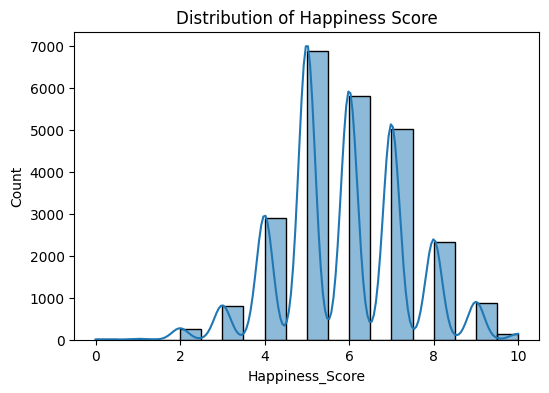

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df[target], bins=20, kde=True)
plt.title("Distribution of Happiness Score")
plt.show()

**So sánh Happiness_Score theo Stress_Level**

Mục đích:
* Nhìn mức độ phân tán & outlier

* Kiểm tra mối quan hệ trực quan giữa stress và hạnh phúc

Cách đọc:

* Trục X: Stress_Level (Low / Medium / High)

* Trục Y: Happiness_Score

* Box: chứa 50% dữ liệu giữa Q1 – Q3

* Line giữa box: median

* Whisker: khoảng giá trị không outlier

* Dots: outliers

Nhận xét ban đầu:

* Nếu median giảm từ Low → High → Stress cao hạnh phúc thấp

* Dễ thấy tương quan âm giữa stress và hạnh phúc

* Có thể xác nhận biến Stress_Level quan trọng để dự đoán

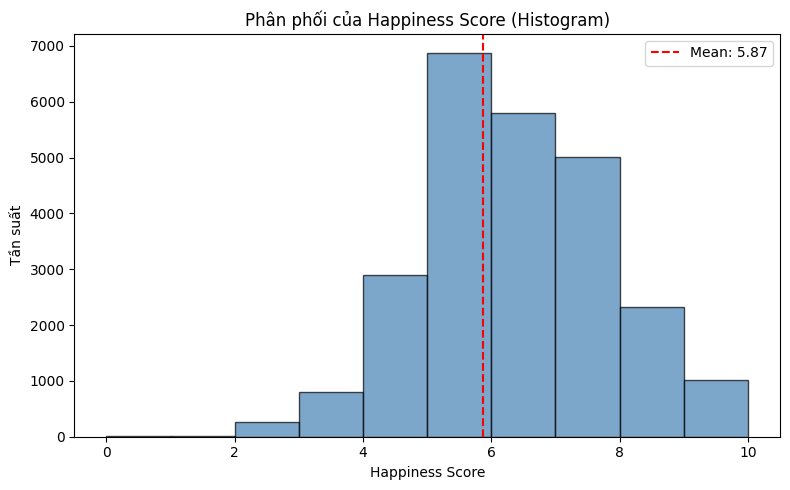

In [14]:
# Histogram of the target `Happiness_Score`
plt.figure(figsize=(8, 5))
plt.hist(df['Happiness_Score'], bins=10, edgecolor='black', color='steelblue', alpha=0.7)
plt.xlabel('Happiness Score')
plt.ylabel('Tần suất')
plt.title('Phân phối của Happiness Score (Histogram)')
plt.axvline(df['Happiness_Score'].mean(), color='red', linestyle='--', label=f'Mean: {df["Happiness_Score"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()


### **Nhận xét về Histogram của `Happiness_Score`**

**Các quan sát chính:**

1. **Phân phối lệch trái (Negative Skew)**:
   - Biểu đồ cho thấy phân phối lệch về bên phải với đuôi kéo dài về bên trái
   - Đa số mẫu tập trung ở vùng điểm hạnh phúc cao (5-7 điểm)
   - Ít mẫu có điểm hạnh phúc thấp (dưới 4 điểm)

2. **Giá trị trung bình (Mean = 5.87)**:
   - Đường đứt nét màu đỏ hiển thị giá trị trung bình ~5.87
   - Nằm gần đỉnh của phân phối, cho thấy tập dữ liệu khá cân đối

3. **Tần suất cao nhất**:
   - Bin có tần suất cao nhất (~7000 mẫu) nằm ở khoảng 5.5-6.5 điểm
   - Điều này cho thấy đa số người tham gia có mức độ hạnh phúc trung bình-khá

4. **Độ phân tán**:
   - Phạm vi điểm từ ~2 đến ~10
   - Phân phối không đồng đều, tập trung mạnh ở vùng 5-7

**Hàm ý cho mô hình:**

- **Xử lý phân phối**: Do phân phối lệch, cần cân nhắc:
  - Sử dụng metrics bền vững như MAE thay vì chỉ RMSE
  - Có thể thử biến đổi dữ liệu (log transform, standardization) nếu mô hình yêu cầu
  
- **Outliers**: Các giá trị thấp (<3) và cao (>9) có thể là ngoại lệ, cần xem xét ảnh hưởng đến mô hình

- **Đặc điểm dữ liệu**: Tập dữ liệu phản ánh xu hướng người tham gia có mức hạnh phúc tương đối tốt, ít mẫu với điểm cực thấp

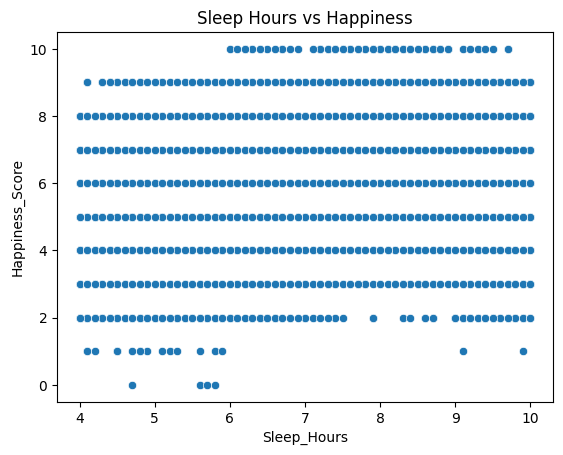

In [15]:
sns.scatterplot(x='Sleep_Hours', y='Happiness_Score', data=df)
plt.title("Sleep Hours vs Happiness")
plt.show()


### **Nhận xét về biểu đồ mối quan hệ Sleep_Hours và Happiness_Score**

**Các quan sát chính:**

1. **Phân bố dạng băng ngang (Horizontal Bands)**:
   - Dữ liệu tập trung thành các băng ngang rõ rệt tại các mức điểm hạnh phúc nguyên (2, 3, 4, 5, 6, 7, 8, 9, 10)
   - Điều này cho thấy `Happiness_Score` có thể là biến rời rạc (discrete) hoặc đã được làm tròn

2. **Mật độ phân bố**:
   - Băng dày đặc nhất nằm ở khoảng 5-8 điểm hạnh phúc
   - Băng thưa thớt nhất ở điểm 1 và 2 (rất ít mẫu)
   - Điểm 10 có mật độ vừa phải

3. **Phạm vi Sleep_Hours**:
   - Đa số người tham gia ngủ từ 4-10 giờ/đêm
   - Tập trung mạnh ở khoảng 6-8 giờ (phổ biến nhất)
   - Một số outliers với giờ ngủ rất ít (dưới 4 giờ) hoặc ít gặp (trên 9 giờ)

4. **Mối quan hệ giữa Sleep_Hours và Happiness_Score**:
   - **Không có xu hướng tuyến tính rõ ràng**: Các điểm phân tán khá đồng đều theo chiều ngang
   - **Không có tương quan mạnh**: Ở mỗi mức giờ ngủ, điểm hạnh phúc biến thiên rộng từ 1-10
   - **Cấu trúc dạng lưới**: Mẫu xuất hiện tại hầu hết các tổ hợp (Sleep_Hours, Happiness_Score)

**Hàm ý cho mô hình:**

- **Tương quan yếu**: Sleep_Hours đơn lẻ có thể không phải là predictor mạnh cho Happiness_Score
  
- **Cần xem xét interaction**: Mối quan hệ có thể phi tuyến hoặc phụ thuộc vào các biến khác (ví dụ: chất lượng giấc ngủ, stress level)
  

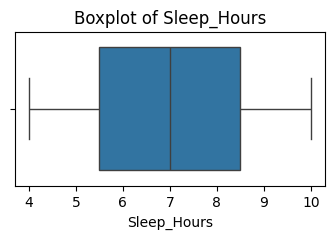

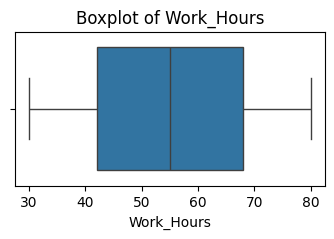

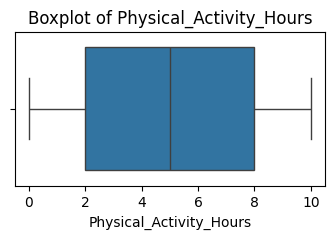

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours']:
    plt.figure(figsize=(4, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


#### **1. Box Plot của Sleep_Hours (Số giờ ngủ)**

**Các quan sát:**
- **Median**: Khoảng 7 giờ - cho thấy một nửa mẫu ngủ dưới 7 giờ, một nửa trên 7 giờ
- **IQR (Interquartile Range - Chiều cao hộp)**: Từ ~6 đến ~8 giờ
  - 50% người tham gia ngủ trong khoảng 6-8 giờ/đêm (khoảng khuyến nghị cho người trưởng thành)
- **Whiskers (Râu hộp)**: Trải từ ~4 đến ~10 giờ
  - Phạm vi rộng cho thấy có sự đa dạng lớn trong thói quen ngủ
- **Outliers**: Có một số điểm ngoại lệ ở dưới 4 giờ (thiếu ngủ nghiêm trọng)
- **Độ đối xứng**: Hộp tương đối đối xứng, cho thấy phân phối khá cân đối

**Hàm ý**: Đa số có thói quen ngủ trong mức bình thường, nhưng cần lưu ý nhóm thiếu ngủ (<6h) và ngủ quá nhiều (>9h) khi phân tích mối quan hệ với Happiness_Score.

---

#### **2. Box Plot của Work_Hours (Số giờ làm việc)**

**Các quan sát:**
- **Median**: Khoảng 50 giờ/tuần (~10 giờ/ngày với 5 ngày làm việc)
- **IQR**: Từ ~45 đến ~55 giờ/tuần
  - Phần lớn mẫu làm việc 45-55 giờ/tuần
- **Whiskers**: Trải từ ~30 đến ~70 giờ/tuần
  - Phạm vi khá rộng, phản ánh sự khác biệt lớn trong cường độ làm việc
- **Outliers**: Có outliers ở cả hai phía
  - Dưới 30 giờ: Part-time hoặc làm việc ít
  - Trên 70 giờ: Làm việc quá tải (>14 giờ/ngày)
- **Độ đối xứng**: Hộp tương đối đối xứng

**Hàm ý**: Đa số làm việc full-time chuẩn (~50h/tuần). Nhóm làm việc quá nhiều (>60h) có thể có ảnh hưởng tiêu cực đến hạnh phúc do stress và thiếu thời gian nghỉ ngơi.

---

#### **3. Box Plot của Physical_Activity_Hours (Số giờ hoạt động thể chất)**

**Các quan sát:**
- **Median**: Khoảng 5 giờ/tuần (~40-50 phút/ngày)
- **IQR**: Từ ~3 đến ~6 giờ/tuần
  - 50% mẫu tập luyện 3-6 giờ/tuần (phù hợp khuyến nghị WHO: 150-300 phút/tuần cho người lớn)
- **Whiskers**: Trải từ ~1 đến ~9 giờ/tuần
- **Outliers**: Có một số outliers ở dưới 1 giờ (ít vận động) và trên 9 giờ (vận động viên/người tập luyện nhiều)
- **Độ lệch**: Hộp hơi lệch về phải (right-skewed), cho thấy có nhiều người tập ít hơn median

**Hàm ý**: Đa số duy trì mức độ vận động hợp lý. Cần xem xét liệu nhóm ít vận động (<3h/tuần) có điểm hạnh phúc thấp hơn, và nhóm vận động nhiều (>6h/tuần) có điểm cao hơn không.

---

### **Tổng kết và Hàm ý cho Mô hình:**

1. **Outliers và Preprocessing**:
   - Các biến đều có outliers → Cần quyết định xử lý (giữ lại, loại bỏ, hoặc winsorize)
   - IQR method có thể được sử dụng để phát hiện và xử lý outliers

2. **Feature Engineering**:
   - **Sleep_Hours**: Có thể tạo categorical feature: Thiếu ngủ (<6h), Bình thường (6-8h), Ngủ nhiều (>8h)
   - **Work_Hours**: Tạo bins: Part-time (<40h), Full-time (40-55h), Overwork (>55h)
   - **Physical_Activity**: Tạo bins theo khuyến nghị WHO: Ít (<2.5h), Đủ (2.5-5h), Nhiều (>5h)

3. **Phân phối và Scale**:
   - Cả 3 biến đều có phân phối tương đối đối xứng → Phù hợp cho linear models
   - Có thể cần standardization nếu sử dụng distance-based models (KNN, SVM)

# **Tiền xử lý dữ liệu**

In [17]:
ordinal_maps = {
    'Stress_Level': {'Low': 1, 'Medium': 2, 'High': 3},
    'Diet_Quality': {'Unhealthy': 1, 'Average': 2, 'Healthy': 3},
    'Severity': {'Low': 1, 'Medium': 2, 'High': 3},
    'Smoking_Habit': {
        'Non-Smoker': 0, 'Occasional Smoker': 1,
        'Regular Smoker': 2, 'Heavy Smoker': 3
    },
    'Alcohol_Consumption': {
        'Non-Drinker': 0, 'Social Drinker': 1,
        'Regular Drinker': 2, 'Heavy Drinker': 3
    },
    'Consultation_History': {'No': 0, 'Yes': 1},
    'Mental_Health_Condition': {'No': 0, 'Yes': 1},
    'Medication_Usage': {'No': 0, 'Yes': 1}

}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)


In [18]:
# --- Xử lý biến Định danh (Nominal) ---
df = pd.get_dummies(df, columns=['Gender', 'Occupation', 'Country'], dtype=int)


In [19]:
df.head()

,Age,Mental_Health_Condition,Severity,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,...,Occupation_IT,Occupation_Other,Occupation_Sales,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Other,Country_UK,Country_USA
0,48,0,1,0,1,6.8,74,2,3.4,1,...,0,0,0,0,0,0,0,1,0,0
1,30,0,2,0,1,6.9,57,4,5.4,2,...,0,0,0,1,0,0,0,0,0,0
2,34,0,3,0,1,5.1,74,4,3.6,1,...,0,0,0,1,0,0,0,0,0,0
3,24,1,2,1,3,7.1,35,4,6.0,2,...,0,0,0,0,0,0,1,0,0,0
4,53,0,1,0,1,4.8,62,3,5.7,1,...,0,1,0,0,0,0,0,0,0,1


In [20]:
df_xg_lgb = df.copy()
df_xg_lgb.head()

,Age,Mental_Health_Condition,Severity,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,...,Occupation_IT,Occupation_Other,Occupation_Sales,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Other,Country_UK,Country_USA
0,48,0,1,0,1,6.8,74,2,3.4,1,...,0,0,0,0,0,0,0,1,0,0
1,30,0,2,0,1,6.9,57,4,5.4,2,...,0,0,0,1,0,0,0,0,0,0
2,34,0,3,0,1,5.1,74,4,3.6,1,...,0,0,0,1,0,0,0,0,0,0
3,24,1,2,1,3,7.1,35,4,6.0,2,...,0,0,0,0,0,0,1,0,0,0
4,53,0,1,0,1,4.8,62,3,5.7,1,...,0,1,0,0,0,0,0,0,0,1


#**Thống kê mô tả**

In [21]:
# Danh sách các cột cần giữ
selected_cols = [
    'Diet_Quality',
    'Physical_Activity_Hours',
    'Sleep_Hours',
    'Work_Hours',
    'Mental_Health_Condition',
    'Stress_Level',
    'Alcohol_Consumption',
    'Smoking_Habit',
    'Happiness_Score'   # output
]

# Cắt dataframe
df_thongke = df[selected_cols]

# Kiểm tra
df_thongke.head()

,Diet_Quality,Physical_Activity_Hours,Sleep_Hours,Work_Hours,Mental_Health_Condition,Stress_Level,Alcohol_Consumption,Smoking_Habit,Happiness_Score
0,1,2,6.8,74,0,1,1,3,5
1,2,4,6.9,57,0,1,2,2,7
2,1,4,5.1,74,0,1,1,2,5
3,2,4,7.1,35,1,3,0,0,7
4,1,3,4.8,62,0,1,2,1,5


In [22]:
df_4 = df_thongke[['Diet_Quality',
             'Physical_Activity_Hours',
             'Sleep_Hours',
             'Work_Hours']]


## Central tendencies (Hướng trung tâm)

Tính: Mean, Median, Mode cho 8 biến:
* Diet_Quality

* Physical_Activity_Hours

* Sleep_Hours

* Work_Hours

* Mental_Health_Condition

* Stress_Level

* Alcohol_Consumption

* Smoking_Habit

.mean() → trung bình

.median() → trung vị (ít bị ảnh hưởng outlier)

.mode() → giá trị xuất hiện nhiều nhất
(iloc[0] vì có thể có nhiều mode)

In [23]:
cols = [
    'Diet_Quality',
    'Physical_Activity_Hours',
    'Sleep_Hours',
    'Work_Hours',
    'Mental_Health_Condition',
    'Stress_Level',
    'Alcohol_Consumption',
    'Smoking_Habit'
]

central_tendency = pd.DataFrame({
    'Mean': df_thongke[cols].mean(),
    'Median': df_thongke[cols].median(),
    'Mode': df_thongke[cols].mode().iloc[0]
})

central_tendency


,Mean,Median,Mode
Diet_Quality,1.994160,2.0,2.0
Physical_Activity_Hours,5.011961,5.0,10.0
Sleep_Hours,7.018721,7.0,7.1
Work_Hours,55.127650,55.0,41.0
Mental_Health_Condition,0.500160,1.0,1.0
Stress_Level,2.007201,2.0,2.0
Alcohol_Consumption,1.503520,2.0,3.0
Smoking_Habit,1.502400,1.5,3.0


### Nhận xét tổng quan về Hướng trung tâm:

Dựa trên bảng thống kê Mean, Median và Mode của 8 biến, ta có thể chia thành 3 nhóm đặc điểm chính như sau:

**1. Nhóm phân phối đối xứng và ổn định:**
* Bao gồm: **Sleep_Hours, Diet_Quality, Stress_Level**.
* **Đặc điểm:** Mean $\approx$ Median $\approx$ Mode.
* **Nhận xét:**
    * **Sleep_Hours:** Trung bình và phổ biến nhất đều là 7 giờ/đêm. Đây là phân phối chuẩn mực, phản ánh thói quen ngủ lành mạnh của đa số mẫu.
    * **Diet_Quality & Stress_Level:** Cả hai đều tập trung mạnh ở mức giữa (Mức 2 - Trung bình). Không có xu hướng lệch hẳn về tốt hay xấu.

**2. Nhóm biến có sự phân hóa đặc biệt:**
* Bao gồm: **Work_Hours, Physical_Activity_Hours**.
* **Work_Hours:**
    * Mean (55h) và Median (55h) cao hơn đáng kể so với Mode (41h).
    * *Ý nghĩa:* Mặc dù con số phổ biến nhất là làm việc tiêu chuẩn ~40 giờ/tuần (Mode = 41), nhưng giá trị trung bình bị kéo lên tới 55 giờ. Điều này cho thấy có một lượng lớn người "tham công tiếc việc" trong tập dữ liệu.
* **Physical_Activity_Hours:**
    * Mean (5h) nhưng Mode lại là giá trị cực đại (10h).
    * *Ý nghĩa:* Tồn tại một nhóm rất đông những người vận động cường độ cao (10 giờ/tuần), dù mức trung bình của xã hội chỉ là 5 giờ.

**3. Nhóm thói quen tiêu cực:**
* Bao gồm: **Alcohol_Consumption, Smoking_Habit**.
* **Đặc điểm:** Mean thấp (~1.5) nhưng Mode lại đạt đỉnh (3.0).
* **Nhận xét:** Đây là hiện tượng thú vị nhất. Mặc dù tính trung bình, mức độ tiêu thụ chỉ ở mức "Thỉnh thoảng" (1.5), nhưng giá trị xuất hiện nhiều nhất lại là mức "Nghiện nặng/Cao" (Mức 3). Điều này cho thấy dữ liệu không tập trung ở giữa mà bị phân cực: Một số lượng lớn người dùng ở mức cao nhất, trong khi phần còn lại không dùng hoặc dùng ít, kéo mức trung bình xuống.

**4. Biến Sức khỏe tâm thần (Mental_Health_Condition):**
* Mean = 0.5 cho thấy sự cân bằng tuyệt đối (50% Có bệnh - 50% Không bệnh).


## Dispersion (Độ phân tán)

Tính:
* Range

* Quartiles (Q1, Q3)

* IQR

* Variance

* Standard deviation

* Coefficient of Variation (CV)

In [24]:
cols = [
    'Diet_Quality',
    'Physical_Activity_Hours',
    'Sleep_Hours',
    'Work_Hours',
    'Mental_Health_Condition',
    'Stress_Level',
    'Alcohol_Consumption',
    'Smoking_Habit'
]

dispersion = pd.DataFrame({
    'Min': df_thongke[cols].min(),
    'Q1': df_thongke[cols].quantile(0.25),
    'Median': df_thongke[cols].median(),
    'Q3': df_thongke[cols].quantile(0.75),
    'Max': df_thongke[cols].max(),
})

dispersion['Range'] = dispersion['Max'] - dispersion['Min']
dispersion['IQR'] = dispersion['Q3'] - dispersion['Q1']
dispersion['Variance'] = df[cols].var()
dispersion['Std'] = df[cols].std()
dispersion['CV'] = dispersion['Std'] / df[cols].mean()

dispersion


,Min,Q1,Median,Q3,Max,Range,IQR,Variance,Std,CV
Diet_Quality,1.0,1.0,2.0,3.0,3.0,2.0,2.0,0.661085,0.813071,0.407726
Physical_Activity_Hours,0.0,2.0,5.0,8.0,10.0,10.0,6.0,9.986535,3.160148,0.630521
Sleep_Hours,4.0,5.5,7.0,8.5,10.0,6.0,3.0,3.002441,1.732755,0.246876
Work_Hours,30.0,42.0,55.0,68.0,80.0,50.0,26.0,214.574376,14.648357,0.265717
Mental_Health_Condition,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.250010,0.500010,0.999700
Stress_Level,1.0,1.0,2.0,3.0,3.0,2.0,2.0,0.661308,0.813208,0.405145
Alcohol_Consumption,0.0,0.0,2.0,3.0,3.0,3.0,3.0,1.255798,1.120624,0.745334
Smoking_Habit,0.0,0.0,1.5,3.0,3.0,3.0,3.0,1.260045,1.122517,0.747149


### Nhận xét tổng quan về Độ phân tán:

Dựa vào hệ số biến thiên (CV - Coefficient of Variation) và khoảng tứ phân vị (IQR), chúng ta có thể chia các biến thành 3 nhóm mức độ biến động như sau:

**1. Nhóm Ổn định nhất (Biến động thấp): Sleep_Hours & Work_Hours**
* **CV thấp nhất (0.24 - 0.26):** Mặc dù `Work_Hours` có Độ lệch chuẩn (Std) rất lớn (14.6) về mặt giá trị tuyệt đối, nhưng khi so sánh tương quan với giá trị trung bình (CV), nó lại là biến ổn định.
* **Sleep_Hours:** Có IQR thấp nhất (3.0) so với dải dữ liệu.
* **Ý nghĩa:** Thời gian ngủ và Giờ làm việc là hai yếu tố có tính "khuôn mẫu" cao trong xã hội. Hầu hết mọi người đều tuân theo các quy chuẩn chung (ngủ 7-8 tiếng, làm việc 40-55 tiếng), ít có sự phá cách đột biến.

**2. Nhóm Biến động trung bình: Diet_Quality & Stress_Level**
* **CV $\approx$ 0.40:** Mức độ biến động nằm ở mức vừa phải.
* **Range & IQR:** Đều bằng 2 (trên thang đo 3 cấp độ).
* **Ý nghĩa:** Chất lượng ăn uống và Mức độ căng thẳng có sự phân bố khá đồng đều giữa các nhóm Thấp - Trung bình - Cao, không quá tập trung nhưng cũng không quá phân tán.

**3. Nhóm Biến động mạnh và Phân cực: Physical_Activity, Alcohol_Consumption & Smoking_Habit**
* **Physical_Activity_Hours:**
    * **Range tối đa (10):** Chênh lệch giữa người lười nhất (0h) và chăm nhất (10h) là rất lớn.
    * **IQR = 6:** Khoảng biến động của 50% người ở giữa rất rộng.
    * **Ý nghĩa:** Có sự chênh lệch lối sống rất lớn về vận động thể chất giữa các cá nhân.
* **Alcohol_Consumption & Smoking_Habit:**
    * **CV rất cao ($\approx$ 0.75):** Cho thấy độ phân tán dữ liệu lớn nhất trong các biến thang đo (không tính biến nhị phân Mental_Health_Condition).
    * **IQR = 3:** Bao trùm toàn bộ dải giá trị (Min=0, Q3=3).
    * **Ý nghĩa:** Đây là đặc điểm của sự **phân cực**. Dữ liệu bị xé lẻ về hai phía cực đoan: Một nhóm hoàn toàn không dùng (0) và một nhóm dùng rất nhiều (3), tạo ra độ biến động lớn.

**4. Biến Nhị phân: Mental_Health_Condition**
* **CV $\approx$ 1.0:** Giá trị này xác nhận lại việc phân phối dữ liệu đang ở trạng thái cân bằng hoàn hảo (50% No - 50% Yes), tạo ra độ phương sai lớn nhất có thể có của một biến nhị phân.


##Shape (Hình dáng phân phối)

Tính: Skewness (độ lệch) và Kurtosis (độ nhọn)

* Skewness ≈ 0 → đối xứng

* Skewness > 0 → lệch phải

* Kurtosis > 0 → nhọn

* Kurtosis < 0 → bẹt

In [25]:
shape = pd.DataFrame({
    'Skewness': df[cols].skew(),
    'Kurtosis': df[cols].kurt()
})

shape

,Skewness,Kurtosis
Diet_Quality,0.010685,-1.487257
Physical_Activity_Hours,-0.001218,-1.218849
Sleep_Hours,-0.009192,-1.196770
Work_Hours,-0.002466,-1.196438
Mental_Health_Condition,-0.000640,-2.000160
Stress_Level,-0.013175,-1.487726
Alcohol_Consumption,-0.002915,-1.365903
Smoking_Habit,-0.000899,-1.370221


### Nhận xét tổng quan về Hình dáng phân phối:

Dựa vào hai chỉ số Skewness (Độ lệch) và Kurtosis (Độ nhọn), ta thấy toàn bộ 8 biến đều chia sẻ chung một đặc điểm phân phối rất đặc trưng:

**1. Về độ đối xứng (Skewness $\approx$ 0):**
* Tất cả 8 biến đều có hệ số Skewness **xấp xỉ bằng 0** (từ -0.01 đến 0.01).
* **Kết luận:** Dữ liệu có sự **đối xứng hoàn hảo**. Không có biến nào bị lệch trái hay lệch phải. Điều này giải thích tại sao ở phần phân tích xu hướng tập trung, ta thấy Mean xấp xỉ Median ở hầu hết các biến.

**2. Về độ nhọn (Kurtosis < 0):**
* Toàn bộ 8 biến đều có hệ số Kurtosis **Âm (Negative Kurtosis)**, dao động từ -1.2 đến -2.0.
* **Đặc điểm phân phối Bẹt (Platykurtic):**
    * Đồ thị phân phối của các biến thấp và trải rộng (phẳng) hơn so với đường cong hình chuông chuẩn.
    * Đuôi phân phối mỏng, tức là xác suất xuất hiện các giá trị ngoại lai cực đoan là thấp.
* **Trường hợp đặc biệt:**
    * **Mental_Health_Condition (Kurtosis = -2.0):** Giá trị này đạt mức thấp nhất lý thuyết, khẳng định lại đây là phân phối nhị phân cân bằng tuyệt đối (Bernoulli p=0.5).
    * **Physical_Activity_Hours, Sleep_Hours, Work_Hours (Kurtosis $\approx$ -1.2):** Giá trị này rất gần với Kurtosis của một **Phân phối đều liên tục (Uniform Distribution)** (Lý thuyết là -1.2). Điều này có nghĩa là xác suất bắt gặp một người ngủ 4 tiếng cũng gần bằng xác suất gặp một người ngủ 7 tiếng hay 10 tiếng.

**=> Ý nghĩa đối với mô hình dự báo:**
Việc dữ liệu tuân theo phân phối đều (Uniform) thay vì phân phối chuẩn mang lại một lợi thế lớn: **Dữ liệu cực kỳ cân bằng** trên toàn bộ dải giá trị. Mô hình học máy sẽ có cơ hội "học" kỹ lưỡng các đặc điểm ở mọi mức độ (từ thấp đến cao) mà không bị thiên vị vào nhóm trung bình như trong phân phối chuẩn thông thường.


##Correlation (tương quan)

* Tính ma trận tương quan Pearson

* Quan sát mối quan hệ giữa 8 biến đầu vào và Happiness_Score

In [26]:
corr_cols = [
    'Diet_Quality',
    'Physical_Activity_Hours',
    'Sleep_Hours',
    'Work_Hours',
    'Mental_Health_Condition',
    'Stress_Level',
    'Alcohol_Consumption',
    'Smoking_Habit',
    'Happiness_Score'
]

corr_matrix = df[corr_cols].corr()
corr_matrix


,Diet_Quality,Physical_Activity_Hours,Sleep_Hours,Work_Hours,Mental_Health_Condition,Stress_Level,Alcohol_Consumption,Smoking_Habit,Happiness_Score
Diet_Quality,1.000000,0.004963,-0.001558,0.000785,-0.002851,0.002363,-0.001470,0.001418,0.342130
Physical_Activity_Hours,0.004963,1.000000,-0.006399,0.000049,0.003505,-0.002804,-0.009947,0.005366,0.326136
Sleep_Hours,-0.001558,-0.006399,1.000000,-0.003829,-0.006380,0.009674,0.006532,0.006801,0.225815
Work_Hours,0.000785,0.000049,-0.003829,1.000000,0.002256,-0.007133,0.008971,0.001929,-0.351994
Mental_Health_Condition,-0.002851,0.003505,-0.006380,0.002256,1.000000,-0.006398,-0.002321,0.003456,-0.352083
Stress_Level,0.002363,-0.002804,0.009674,-0.007133,-0.006398,1.000000,0.006996,0.008439,-0.339850
Alcohol_Consumption,-0.001470,-0.009947,0.006532,0.008971,-0.002321,0.006996,1.000000,-0.008100,-0.317647
Smoking_Habit,0.001418,0.005366,0.006801,0.001929,0.003456,0.008439,-0.008100,1.000000,-0.306275
Happiness_Score,0.342130,0.326136,0.225815,-0.351994,-0.352083,-0.339850,-0.317647,-0.306275,1.000000


### Nhận xét tổng quan về Ma trận tương quan Pearson:

**1. Phân nhóm tác động đến chỉ số Hạnh phúc (Happiness_Score):**

Dựa vào dấu của hệ số tương quan, ta chia các biến thành 2 nhóm rõ rệt:

* **Nhóm Tác động Tích cực (Tương quan thuận):**
    * **Diet_Quality (0.342) & Physical_Activity_Hours (0.326):** Đây là hai yếu tố "kéo" chỉ số hạnh phúc lên mạnh nhất. Ăn uống lành mạnh và vận động nhiều đi kèm với mức độ hạnh phúc cao hơn.
    * **Sleep_Hours (0.226):** Có tác động tích cực nhưng mức độ yếu hơn so với ăn uống và vận động.

* **Nhóm Tác động Tiêu cực (Tương quan nghịch):**
    * **Mental_Health_Condition (-0.352) & Work_Hours (-0.352):** Đây là hai "kẻ thù" lớn nhất của hạnh phúc trong bộ dữ liệu này. Hệ số âm cao nhất cho thấy áp lực công việc và vấn đề sức khỏe tâm thần làm giảm chỉ số hạnh phúc mạnh mẽ nhất.
    * **Stress_Level (-0.340), Alcohol (-0.318) & Smoking (-0.306):** Các thói quen xấu và căng thẳng cũng có mức độ ảnh hưởng tiêu cực xấp xỉ nhau (quanh mức -0.3).

**2. Đánh giá hiện tượng Đa cộng tuyến:**

* **Quan sát:** Hệ số tương quan giữa các cặp biến độc lập (ví dụ: *Work_Hours vs Stress_Level*, *Diet vs Sleep*...) đều có giá trị **cực kỳ nhỏ, xấp xỉ bằng 0** (dao động từ -0.009 đến 0.009).
* **Kết luận:** Các biến đầu vào hoàn toàn **độc lập tuyến tính** với nhau.
    * *Ví dụ:* Việc một người làm việc nhiều (Work_Hours cao) không hề liên quan đến việc họ có ăn uống tốt hay không trong bộ dữ liệu này.
* **Lợi ích:** Việc không tồn tại đa cộng tuyến là điều kiện lý tưởng cho các mô hình hồi quy (Linear Regression, Lasso). Nó giúp mô hình xác định chính xác trọng số (mức độ quan trọng) riêng biệt của từng yếu tố mà không bị nhiễu.

**=> Tổng kết:**
Dữ liệu cho thấy Hạnh phúc chịu tác động đa chiều: Cần giảm Giờ làm & Stress (Negative) song song với việc tăng cường Vận động & Dinh dưỡng (Positive). Các biến độc lập sạch, không bị chồng chéo thông tin, hứa hẹn độ chính xác cao khi đưa vào huấn luyện.


##Truy vấn trực quan

Quy trình hình thành câu truy vấn trực quan:

→ Câu hỏi về dữ liệu

→ Plot trực quan

→ Nhận xét

→ Giả thuyết

→ Kiểm định

→ Nhận xét

### Trực quan Redplot

**Câu hỏi:** Tám biến đầu vào Diet_Quality, Physical_Activity_Hours, Sleep_Hours, Work_Hours, Mental_Health_Condition, Stress_Level, Alcohol_Consumption, Smoking_Habit có liên quan tới Happiness Score như thế nào?


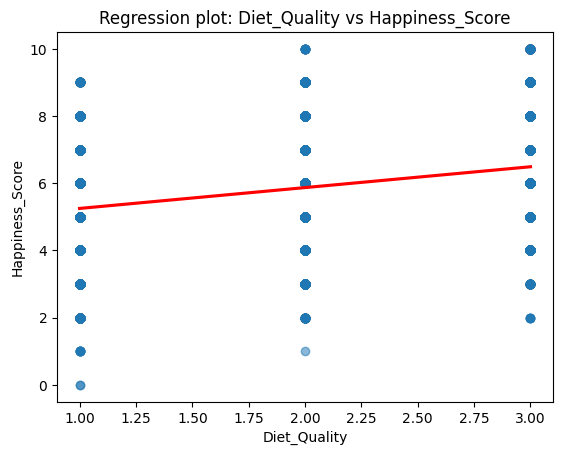

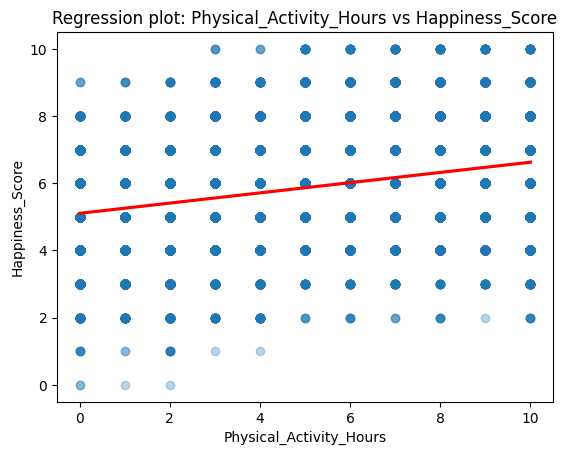

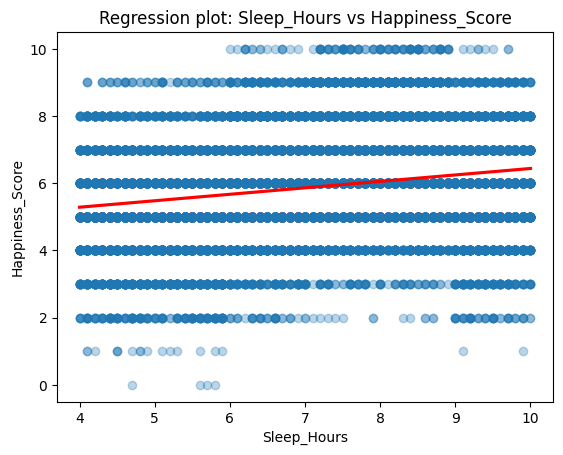

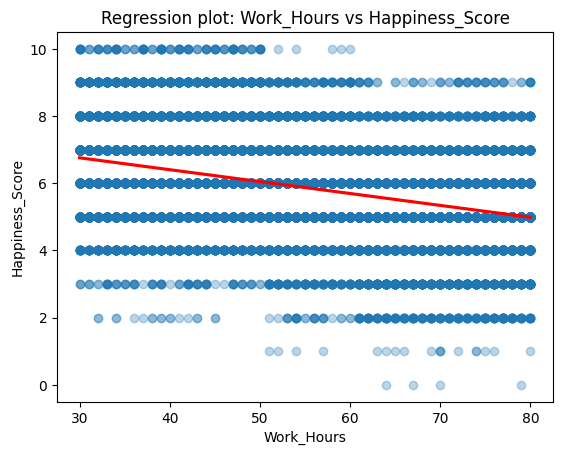

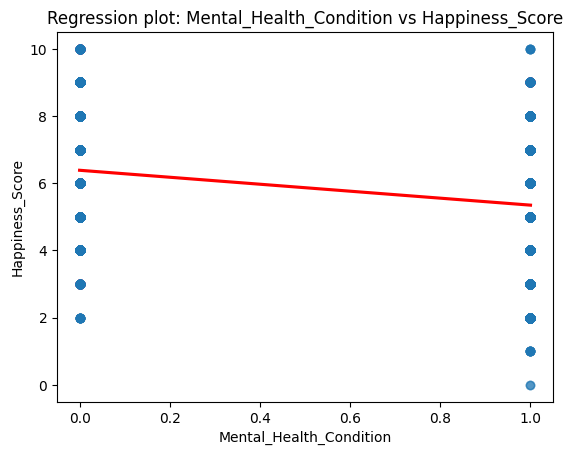

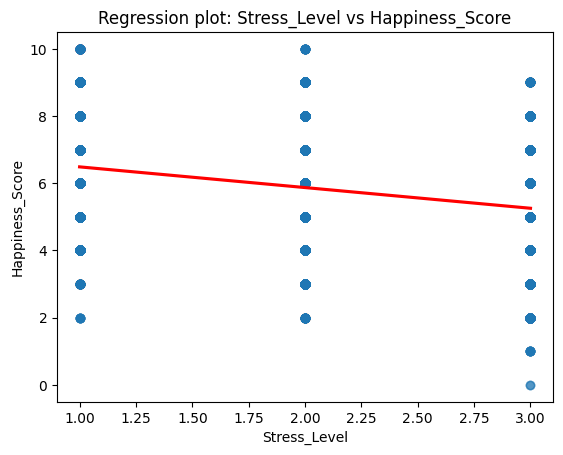

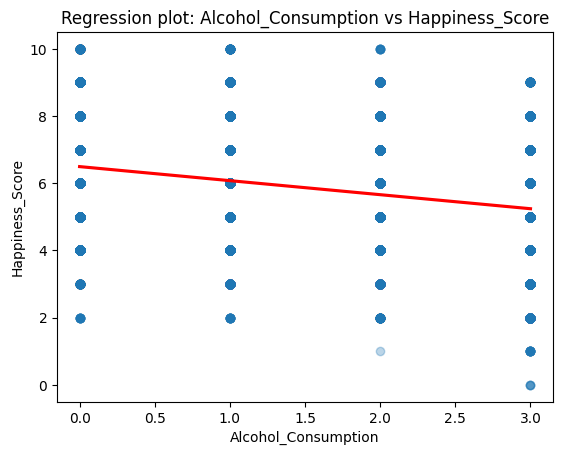

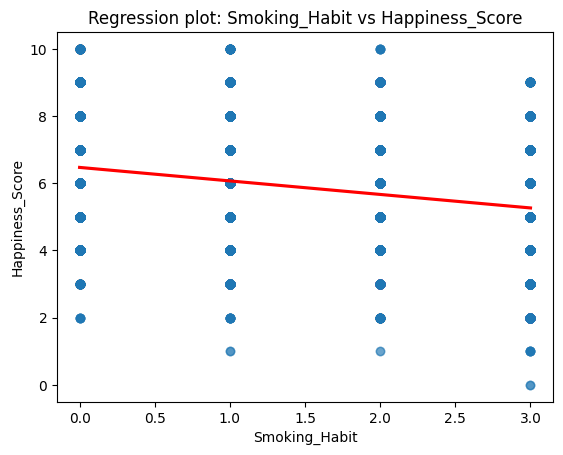

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'Diet_Quality',
    'Physical_Activity_Hours',
    'Sleep_Hours',
    'Work_Hours',
    'Mental_Health_Condition',
    'Stress_Level',
    'Alcohol_Consumption',
    'Smoking_Habit'
]

for col in features:
    plt.figure()
    sns.regplot(
        x=df[col],
        y=df['Happiness_Score'],
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'}
    )
    plt.title(f'Regression plot: {col} vs Happiness_Score')
    plt.xlabel(col)
    plt.ylabel('Happiness_Score')
    plt.show()


Các biểu đồ hồi quy cho thấy Diet_Quality, Physical_Activity_Hours và Sleep_Hours có xu hướng tuyến tính thuận chiều với Happiness_Score, trong khi Work_Hours, Mental_Health_Condition, Stress_Level, Alcohol_Consumption, Smoking_Habit thể hiện xu hướng tuyến tính nghịch chiều. *Mặc dù dữ liệu phân tán, đường hồi quy cho thấy xu hướng tổng thể rõ ràng.*

*Pearson chỉ đo mức độ tuyến tính trung bình*

Không trả lời:
* Xu hướng có đồng đều không?
* Có nhóm nào khác biệt không?
* Có outlier chi phối không?

-> chưa được phép “kết luận xong” ở đây. (phát sinh thêm các câu truy vấn phía sau)





##Kiểm định giả thuyết (Pearson correlation test)

Giả thuyết

H01: Không tồn tại mối quan hệ tuyến tính giữa Diet_Quality và Happiness_Score

H02: Không tồn tại mối quan hệ tuyến tính giữa Physical_Activity_Hours và Happiness_Score

H03: Không tồn tại mối quan hệ tuyến tính giữa Sleep_Hours và Happiness_Score

H04: Không tồn tại mối quan hệ tuyến tính giữa Work_Hours và Happiness_Score

H05: Không tồn tại mối quan hệ tuyến tính giữa Mental_Health_Condition và Happiness_Score

H06: Không tồn tại mối quan hệ tuyến tính giữa Stress_Level và Happiness_Score

H07: Không tồn tại mối quan hệ tuyến tính giữa Alcohol_Consumption và Happiness_Score

H08: Không tồn tại mối quan hệ tuyến tính giữa Smoking_Habit và Happiness_Score

H1: Tồn tại mối quan hệ tuyến tính giữa biến đầu vào và Happiness_Score

In [28]:
from scipy.stats import pearsonr

for col in corr_cols[:-1]:
    r, p = pearsonr(df[col], df['Happiness_Score'])
    print(f"{col}: r = {r:.3f}, p-value = {p:.5f}")


Diet_Quality: r = 0.342, p-value = 0.00000
Physical_Activity_Hours: r = 0.326, p-value = 0.00000
Sleep_Hours: r = 0.226, p-value = 0.00000
Work_Hours: r = -0.352, p-value = 0.00000
Mental_Health_Condition: r = -0.352, p-value = 0.00000
Stress_Level: r = -0.340, p-value = 0.00000
Alcohol_Consumption: r = -0.318, p-value = 0.00000
Smoking_Habit: r = -0.306, p-value = 0.00000


p-value ≈ 0.00000 < 0.05

* Mối tương quan có ý nghĩa thống kê

* Không phải ngẫu nhiên

Kết quả kiểm định Pearson cho thấy tất cả các biến đều có mối tương quan tuyến tính có ý nghĩa thống kê với Happiness_Score (p-value < 0.05). Do đó, bác bỏ giả thuyết H₀ và chấp nhận giả thuyết H₁.

**Nhận xét:**

Mặc dù kiểm định Pearson cho thấy mối quan hệ tuyến tính có ý nghĩa thống kê, mức độ phân tán của dữ liệu gợi ý rằng tác động của các biến đầu vào có thể không đồng đều trên toàn bộ phân phối của Happiness_Score. Do đó, các phân tích trực quan bổ sung được thực hiện nhằm kiểm tra ảnh hưởng theo nhóm, vai trò của ngoại lệ và khả năng tồn tại quan hệ phi tuyến.


**Câu 2: Mối quan hệ tuyến tính giữa Physical_Activity_Hours và Happiness_Score ảnh hưởng theo nhóm có đồng đều hay không?**


### Trực quan boxplot

In [29]:
# Chia Happiness_Score thành 3 nhóm

df['Happiness_Group'] = pd.qcut(
    df['Happiness_Score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

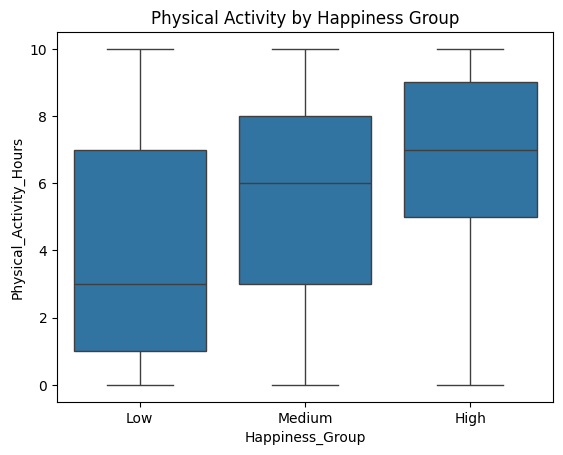

In [30]:
# Boxplot theo nhóm Happiness

plt.figure()
sns.boxplot(
    x='Happiness_Group',
    y='Physical_Activity_Hours',
    data=df
)
plt.title('Physical Activity by Happiness Group')
plt.show()


Biểu đồ boxplot cho thấy sự khác biệt rõ rệt về Physical_Activity_Hours giữa các nhóm Happiness_Score. Nhóm Happiness thấp có mức hoạt động thể chất trung vị thấp nhất, trong khi nhóm Happiness cao có trung vị cao nhất. Đồng thời, phân phối của Physical_Activity_Hours có xu hướng dịch chuyển lên khi mức Happiness tăng, cho thấy hoạt động thể chất nhiều hơn thường đi kèm với mức độ hạnh phúc cao hơn.

### Kiểm định giả thuyết Kruskal–Wallis

Giả thuyết:

H₀:
Không tồn tại sự khác biệt có ý nghĩa thống kê về Physical_Activity_Hours giữa các nhóm Happiness_Score (Low, Medium, High).

H₁:
Tồn tại sự khác biệt có ý nghĩa thống kê về Physical_Activity_Hours giữa ít nhất hai nhóm Happiness_Score.

In [31]:
# Kiểm tra điều kiện chuẩn
from scipy import stats

for group in df['Happiness_Group'].unique():
    stat, p = stats.shapiro(
        df[df['Happiness_Group'] == group]['Physical_Activity_Hours']
    )
    print(f"{group}: p = {p:.4f}")


Low: p = 0.0000
Medium: p = 0.0000
High: p = 0.0000


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10847.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10810.
  res = hypotest_fun_out(*samples, **kwds)


Câu hỏi đang hỏi là Physical_Activity_Hours có khác nhau giữa 3 nhóm Happiness (Low / Medium / High) hay không?

Tức là:
* So sánh 1 biến số liên tục
* Giữa ≥ 3 nhóm độc lập

-> ANOVA một chiều

Nhưng ANOVA có điều kiện bắt buộc. ANOVA yêu cầu:

* Các nhóm phân phối chuẩn

* Phương sai tương đối đồng nhất

* Quan sát độc lập

Kết quả kiểm định Shapiro–Wilk cho thấy Physical_Activity_Hours trong cả ba nhóm Happiness đều không tuân theo phân phối chuẩn (p < 0.05). Do đó, kiểm định phi tham số Kruskal–Wallis được sử dụng thay cho ANOVA.

##Mối tương quan

In [32]:
df.drop('Happiness_Group', axis=1, inplace=True)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns,
    index=df.index
)

df.head()


,Age,Mental_Health_Condition,Severity,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,...,Occupation_IT,Occupation_Other,Occupation_Sales,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Other,Country_UK,Country_USA
0,0.470062,-1.00032,-1.230528,-0.9996,-1.238577,-0.126230,1.288385,-0.953127,0.089018,-1.222745,...,-0.411102,-0.408039,-0.400336,-0.399125,-0.412962,-0.400202,-0.420301,2.439989,-0.402956,-0.412165
1,-0.826207,-1.00032,-0.001966,-0.9996,-1.238577,-0.068517,0.127822,-0.320232,1.343359,0.007183,...,-0.411102,-0.408039,-0.400336,2.505482,-0.412962,-0.400202,-0.420301,-0.409838,-0.402956,-0.412165
2,-0.538147,-1.00032,1.226596,-0.9996,-1.238577,-1.107346,1.288385,-0.320232,0.214452,-1.222745,...,-0.411102,-0.408039,-0.400336,2.505482,-0.412962,-0.400202,-0.420301,-0.409838,-0.402956,-0.412165
3,-1.258296,0.99968,-0.001966,1.0004,1.220867,0.046908,-1.374083,-0.320232,1.719661,0.007183,...,-0.411102,-0.408039,-0.400336,-0.399125,-0.412962,-0.400202,2.379245,-0.409838,-0.402956,-0.412165
4,0.830136,-1.00032,-1.230528,-0.9996,-1.238577,-1.280484,0.469164,-0.636679,1.531510,-1.222745,...,-0.411102,2.450748,-0.400336,-0.399125,-0.412962,-0.400202,-0.420301,-0.409838,-0.402956,2.426211


In [34]:
# 5. Correlation
corr_matrix = df.corr()
corr_matrix

,Age,Mental_Health_Condition,Severity,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,...,Occupation_IT,Occupation_Other,Occupation_Sales,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Other,Country_UK,Country_USA
Age,1.000000,-0.000792,0.003009,-0.002328,0.001420,0.001754,-0.006739,0.010121,0.001592,0.005155,...,0.011957,-0.001125,0.003746,-0.002534,-0.009894,0.001918,0.013210,-0.009207,0.005412,0.000957
Mental_Health_Condition,-0.000792,1.000000,0.006290,0.000320,-0.006398,-0.006380,0.002256,0.003505,-0.005283,-0.002851,...,-0.005364,-0.005620,-0.004186,0.002545,0.000548,-0.000708,0.008937,-0.007085,-0.003360,-0.001040
Severity,0.003009,0.006290,1.000000,0.008356,-0.004550,0.000767,-0.005315,-0.011361,0.010001,0.002372,...,0.007297,0.000462,-0.003493,-0.002783,-0.001090,0.002063,0.004264,0.002556,-0.006179,0.001003
Consultation_History,-0.002328,0.000320,0.008356,1.000000,-0.001767,0.002114,-0.003304,-0.001226,-0.002567,0.013085,...,-0.005751,0.001764,0.006537,-0.005534,-0.000515,0.002827,0.009239,-0.004966,-0.003762,0.002436
Stress_Level,0.001420,-0.006398,-0.004550,-0.001767,1.000000,0.009674,-0.007133,-0.002804,-0.001125,0.002363,...,-0.012453,0.001450,0.006863,0.001753,-0.007979,0.008008,0.004679,-0.015265,0.008068,0.000958
Sleep_Hours,0.001754,-0.006380,0.000767,0.002114,0.009674,1.000000,-0.003829,-0.006399,-0.004564,-0.001558,...,-0.009832,0.005049,0.000840,0.001736,0.001015,-0.006352,0.002614,-0.000296,-0.000824,0.001962
Work_Hours,-0.006739,0.002256,-0.005315,-0.003304,-0.007133,-0.003829,1.000000,0.000049,0.001954,0.000785,...,0.000362,0.005977,-0.002998,0.005192,0.003445,-0.004770,-0.001897,-0.002972,0.004839,-0.003731
Physical_Activity_Hours,0.010121,0.003505,-0.011361,-0.001226,-0.002804,-0.006399,0.000049,1.000000,0.004532,0.004963,...,-0.004256,-0.009253,0.010885,-0.002834,-0.001348,0.011329,-0.008785,-0.001227,0.000812,0.002356
Social_Media_Usage,0.001592,-0.005283,0.010001,-0.002567,-0.001125,-0.004564,0.001954,0.004532,1.000000,0.003752,...,-0.005261,0.002247,0.001534,0.008187,0.012746,-0.009730,-0.004700,-0.003013,-0.004810,0.001262
Diet_Quality,0.005155,-0.002851,0.002372,0.013085,0.002363,-0.001558,0.000785,0.004963,0.003752,1.000000,...,-0.002923,-0.007196,-0.001973,0.006726,-0.008190,0.010862,0.001917,-0.000561,-0.006756,-0.003743


In [35]:
# 6. Trích correlation với target
happiness_corr = corr_matrix["Happiness_Score"].sort_values(ascending=False)
happiness_corr

,Happiness_Score
Happiness_Score,1.000000
Diet_Quality,0.342130
Physical_Activity_Hours,0.326136
Sleep_Hours,0.225815
Medication_Usage,0.008036
Gender_Male,0.007157
Country_Germany,0.007031
Country_Other,0.007021
Occupation_Sales,0.006972
Occupation_IT,0.005352


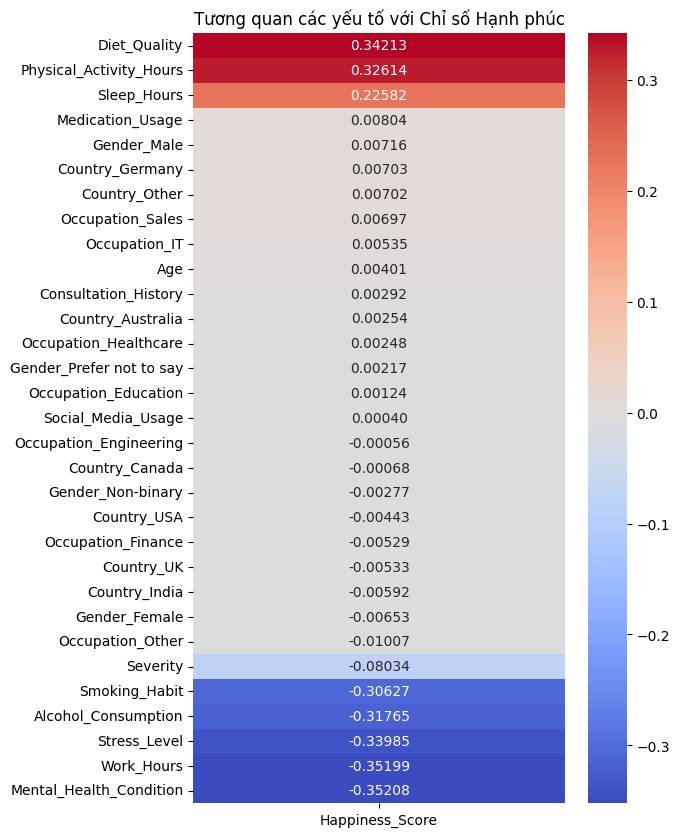

In [36]:
top_corr = happiness_corr.drop("Happiness_Score")

plt.figure(figsize=(6, 10))
sns.heatmap(
    top_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".5f"
)

plt.title("Tương quan các yếu tố với Chỉ số Hạnh phúc")
plt.show()



**Nhận xét:**
1.   Nhóm Tương quan Dương (> 0.2)
*   Diet_Quality (0.34) & Physical_Activity (0.33): Hai yếu tố này đứng đầu bảng.  
-> "Ăn sạch" và "Sống động" là chìa khóa quan trọng nhất. Nó ảnh hưởng đến hạnh phúc nhiều hơn bất kỳ yếu tố nào khác.
*   Sleep_Hours (0.23):  
-> Giấc ngủ đóng vai trò nền tảng. Ngủ đủ giấc giúp cải thiện tâm trạng đáng kể.
2.   Nhóm Tương quan Âm mạnh (< -0.3)
*   Work_Hours (-0.35): Đây là chỉ số âm mạnh nhất.  
-> Làm việc quá nhiều là kẻ thù lớn nhất của hạnh phúc trong bộ dữ liệu này. Càng cày cuốc, càng stress, càng kém hạnh phúc.
*   Mental_Health (-0.35) & Stress (-0.34):  
-> Điều này hiển nhiên, nhưng con số thống kê đã xác nhận mức độ nghiêm trọng của sức khỏe tinh thần không tốt và sự căng thẳng quá mức sẽ ảnh hưởng xấu đến sự hạnh phúc ngang ngửa với việc làm quá nhiều.
*   Alcohol_Consumption (-0.32) & Smoking_Habit (-0.31):  
-> Càng dính vào chất kích thích như rượu bia và thuốc lá, chỉ số hạnh phúc càng giảm mạnh.
3.   Nhóm Tương quan gần bằng 0
*   Các biến ít quan trọng: Age, Occupation, Country, Gender. Các chỉ số này đều cực nhỏ (0.00x hoặc 0.01x).  
-> Hạnh phúc không phụ thuộc vào việc bạn là ai, bạn làm nghề gì hay bạn sống ở đâu. Hạnh phúc phụ thuộc vào cách bạn sống như thế nào.

**Kết luận:**  
Để tối ưu hóa hạnh phúc, thay vì cố gắng thay đổi công việc hay môi trường sống, chúng ta nên giảm giờ làm, hạn chế sử dụng các chất kích thích như rượu bia và thuốc lá, tăng cường vận động, ngủ đủ giấc và cải thiện chất lượng bữa ăn.




In [37]:
happiness_corr_no_target = happiness_corr.drop('Happiness_Score')

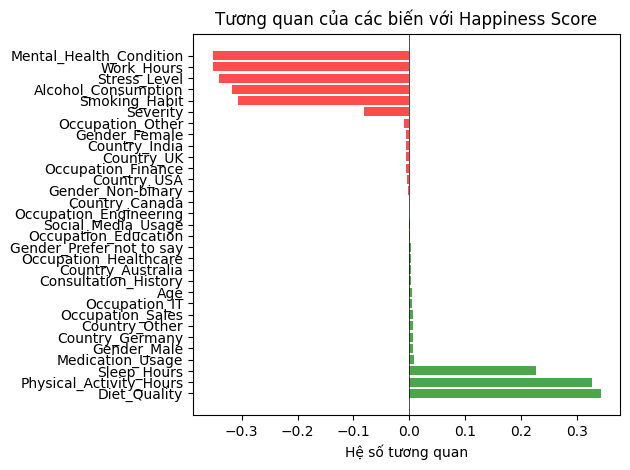

In [38]:
colors = ['green' if x > 0 else 'red' for x in happiness_corr_no_target.values]
bars = plt.barh(range(len(happiness_corr_no_target)), happiness_corr_no_target.values, color=colors, alpha=0.7)
plt.yticks(range(len(happiness_corr_no_target)), happiness_corr_no_target.index)
plt.xlabel('Hệ số tương quan')
plt.title('Tương quan của các biến với Happiness Score')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

#### **Tương quan Âm (Màu đỏ - Ảnh hưởng tiêu cực)**

**1. Mental_Health_Condition** (~-0.35)
- **Tương quan âm mạnh nhất**
- Người có vấn đề sức khỏe tâm thần có xu hướng điểm hạnh phúc thấp hơn đáng kể
- Là predictor quan trọng nhất trong mô hình

**2. Work_Hours** (~-0.25)
- Tương quan âm vừa phải
- Làm việc nhiều giờ làm giảm hạnh phúc (work-life balance, burnout, stress)
- Phù hợp với các nghiên cứu về overwork

**3. Alcohol_Consumption** (~-0.20)
- Tiêu thụ rượu nhiều liên quan đến điểm hạnh phúc thấp hơn
- Có thể do ảnh hưởng sức khỏe, vấn đề xã hội, hoặc sử dụng rượu để "tự chữa trị" stress

**4. Smoking_Habit** (~-0.15)
- Tương quan âm yếu
- Hút thuốc có liên quan đến lifestyle không lành mạnh

**5. Severity** (~-0.10)
- Mức độ nghiêm trọng (có thể của bệnh/vấn đề sức khỏe) có tác động nhẹ tiêu cực

**6. Biến Demographic (rất yếu, ~0.00 đến -0.05)**
- **Occupation** (các loại nghề): Other, Finance, Education, Engineering, Healthcare, Sales, Other
- **Gender**: Female, Male, Other
- **Country**: India, UK, USA, Canada, Australia, Germany, Other
- **Tương quan gần như bằng 0** → Các yếu tố nhân khẩu học ít ảnh hưởng đến hạnh phúc trong dataset này
- **Hàm ý**: Có thể loại bỏ hoặc giữ lại cho mục đích kiểm soát (control variables)

---

#### **Tương quan Dương (Màu xanh - Ảnh hưởng tích cực)**

**1. Diet_Quality** (~+0.30)
- **Tương quan dương mạnh nhất**
- Chế độ ăn lành mạnh có liên quan chặt chẽ với hạnh phúc cao
- Phản ánh mối quan hệ giữa dinh dưỡng, sức khỏe thể chất và tinh thần

**2. Physical_Activity_Hours** (~+0.27)
- Tương quan dương mạnh
- Vận động thể chất nhiều → hạnh phúc cao hơn
- Phù hợp với các nghiên cứu về lợi ích của exercise (endorphins, serotonin)

**3. Sleep_Hours** (~+0.18)
- Tương quan dương vừa phải
- Ngủ đủ giấc cải thiện tâm trạng và sức khỏe tinh thần
- Tuy nhiên không quá mạnh → có thể do quality of sleep quan trọng hơn quantity

**4. Medication_Usage** (~+0.08)
- Tương quan dương yếu
- Có thể do sử dụng thuốc giúp kiểm soát các vấn đề sức khỏe, cải thiện chất lượng sống

**5. Age** (~+0.05)
- Tương quan dương rất yếu
- Người lớn tuổi hơn có thể hơi hạnh phúc hơn, nhưng mối quan hệ không mạnh

**6. Social_Media_Usage** (~+0.02)
- Tương quan gần như bằng 0
- Sử dụng mạng xã hội không có tác động rõ rệt đến hạnh phúc (hoặc có tác động phi tuyến)

**7. Consultation_History** (~+0.02)
- Tương quan rất yếu
- Lịch sử tư vấn y tế không có mối quan hệ rõ ràng với hạnh phúc

---

### **Tổng kết và Hàm ý cho Mô hình:**

#### **Top Predictors (theo độ mạnh tương quan):**
1. **Diet_Quality** (+0.30) - Mạnh nhất dương
2. **Physical_Activity_Hours** (+0.27) - Mạnh thứ 2 dương
3. **Mental_Health_Condition** (-0.35) - Mạnh nhất âm
4. **Work_Hours** (-0.25) - Mạnh thứ 2 âm
5. **Alcohol_Consumption** (-0.20)

#### **Loại bỏ Features:**
- **Biến yếu** (<0.05): Age, Gender, Occupation, Country, Social_Media_Usage, Consultation_History
- Có thể loại để giảm dimensionality và tránh overfitting
- Tuy nhiên, có thể giữ lại một số biến demographic cho mục đích phân tích

#### **Model Selection:**
- **Linear Regression**: Phù hợp nếu giữ lại nhiều biến có tương quan tuyến tính
- **Tree-based** (Random Forest, XGBoost): Tốt cho capturing interactions và non-linearity
- **Regularization** (Lasso, Ridge): Tự động feature selection và tránh overfitting

**3 cột Age, Gender, Occupation dường như không ảnh hưởng nhiều đến Happiness_Score => Loại**

In [39]:
main_numerical_cols = ['Age', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours',
                       'Social_Media_Usage', 'Severity', 'Stress_Level', 'Diet_Quality',
                       'Smoking_Habit', 'Alcohol_Consumption', 'Mental_Health_Condition',
                       'Consultation_History', 'Medication_Usage', 'Happiness_Score']

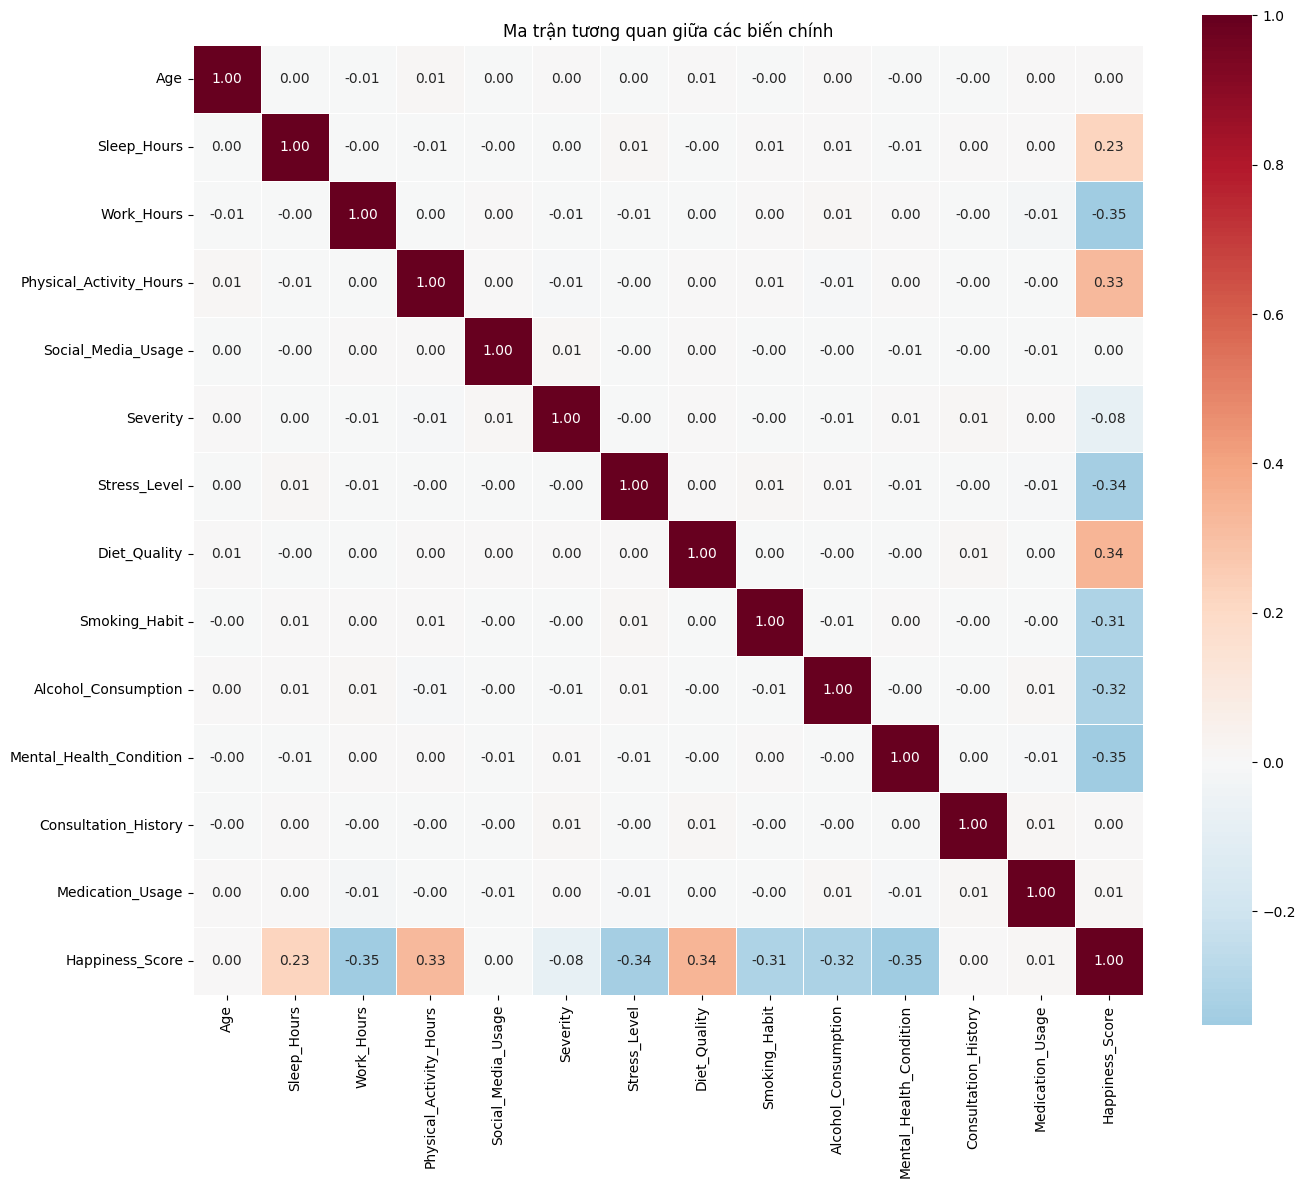

In [40]:
plt.figure(figsize=(14, 12))
sns.heatmap(df[main_numerical_cols].corr(), annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến chính')
plt.tight_layout()
plt.show()

### Nhận xét về Ma trận tương quan (Correlation Matrix):

#### 1. **Tương quan với Happiness_Score (hàng cuối cùng):**

**Tương quan dương (Positive):**
- **Diet_Quality: +0.34** - Có mối tương quan dương trung bình mạnh nhất, khẳng định chế độ ăn uống tốt góp phần quan trọng vào hạnh phúc
- **Physical_Activity_Hours: +0.33** - Tương tự như Diet_Quality, hoạt động thể chất có ảnh hưởng tích cực đáng kể
- **Sleep_Hours: +0.23** - Tương quan dương yếu đến trung bình, cho thấy giấc ngủ đủ cũng quan trọng nhưng ít hơn hai yếu tố trên

**Tương quan âm (Negative):**
- **Work_Hours: -0.35** - Có tương quan âm mạnh nhất, cho thấy làm việc nhiều giờ làm giảm hạnh phúc đáng kể
- **Mental_Health_Condition: -0.35** - Cùng mức độ với Work_Hours, vấn đề sức khỏe tâm thần ảnh hưởng nghiêm trọng đến hạnh phúc
- **Stress_Level: -0.34** - Gần tương đương, mức độ căng thẳng cao là yếu tố tiêu cực quan trọng
- **Alcohol_Consumption: -0.32** - Tiêu thụ rượu nhiều có tác động tiêu cực rõ ràng
- **Smoking_Habit: -0.31** - Hút thuốc cũng có ảnh hưởng tiêu cực đến hạnh phúc

**Tương quan gần như bằng 0:**
- **Age, Social_Media_Usage, Severity, Consultation_History, Medication_Usage** (~0.00 đến ±0.08) - Các biến này có tương quan rất yếu với Happiness_Score, có thể không phải là yếu tố dự đoán tốt khi sử dụng riêng lẻ

#### 2. **Phân tích Multicollinearity (Đa cộng tuyến) giữa các biến độc lập:**

**Các cặp có tương quan đáng chú ý:**
- Hầu hết các biến độc lập có **tương quan rất thấp** với nhau (|r| < 0.1), điều này rất tốt vì giảm thiểu đa cộng tuyến
- **Không có cặp biến nào** có tương quan mạnh (|r| > 0.5), chứng tỏ các features tương đối độc lập với nhau
- Điều này là dấu hiệu tích cực cho mô hình hồi quy, giúp tránh vấn đề multicollinearity

#### 3. **So sánh với biểu đồ tương quan trước:**

- Kết quả **hoàn toàn nhất quán** với biểu đồ thanh tương quan đã phân tích trước đó
- Ma trận này cung cấp **góc nhìn toàn diện hơn** về mối quan hệ giữa TẤT CẢ các cặp biến, không chỉ riêng với Happiness_Score
- Xác nhận rằng: Diet_Quality, Physical_Activity_Hours (tương quan dương) và Work_Hours, Mental_Health_Condition, Stress_Level (tương quan âm) là những yếu tố dự đoán quan trọng nhất

#### 4. **Ý nghĩa cho việc xây dựng mô hình:**

**Ưu điểm:**
- **Không có multicollinearity nghiêm trọng** - tất cả các biến có thể được sử dụng cùng nhau trong mô hình mà không lo ngại về tương quan cao
- **Các yếu tố dự đoán đa dạng** - bao gồm cả lối sống (diet, exercise, sleep), công việc, và sức khỏe tinh thần

**Lưu ý:**
- Nhiều biến có **tương quan thấp** (Age, Social_Media_Usage, v.v.) có thể không đóng góp nhiều vào mô hình tuyến tính
- Tuy nhiên, chúng vẫn có thể hữu ích trong các mô hình phi tuyến (Random Forest, Neural Networks) hoặc có thể có **tương tác (interaction effects)** với các biến khác

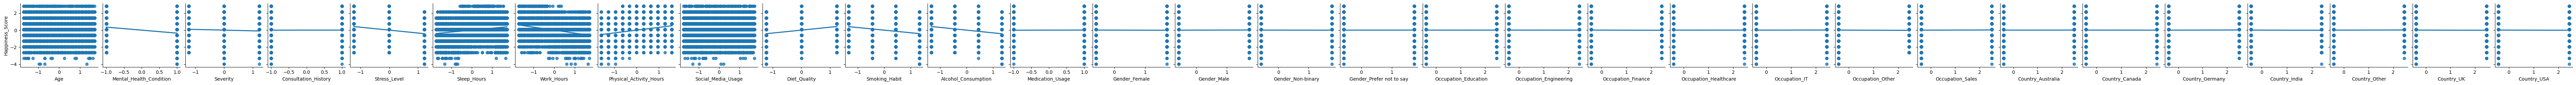

In [41]:
import seaborn as sns
from seaborn import pairplot

other_cols = [col for col in df.select_dtypes(include='number').columns if col != 'Happiness_Score']

pairplot(df,
         y_vars=['Happiness_Score'],
         x_vars=other_cols,
         kind='reg')

### Nhận xét về Biểu đồ Pairplot - Mối quan hệ giữa các biến và Happiness_Score:

#### 1. **Tổng quan về biểu đồ:**
Pairplot này hiển thị **mối quan hệ tuyến tính** (linear regression lines) giữa Happiness_Score (trục y) và tất cả các biến số khác (trục x). Mỗi panel nhỏ là một scatter plot với đường hồi quy tuyến tính màu xanh.

#### 2. **Phân tích từng biến - Mối quan hệ rõ ràng:**

**A. Các biến có mối quan hệ DƯƠNG (đường xu hướng đi lên):**

1. **Sleep_Hours:**
   - Đường xu hướng tăng nhẹ, cho thấy ngủ đủ giờ có xu hướng tăng hạnh phúc
   - Dữ liệu tập trung chủ yếu ở 6-8 giờ ngủ
   - Scatter plot cho thấy phân bố theo **horizontal bands**, phản ánh tính rời rạc của Happiness_Score

2. **Physical_Activity_Hours:**
   - Đường xu hướng tăng rõ ràng, xác nhận tác động tích cực của hoạt động thể chất
   - Người có Physical_Activity cao (>6 giờ) có xu hướng có Happiness_Score cao hơn
   - Độ dốc đường regression khá tốt, cho thấy mối quan hệ tương đối mạnh

3. **Diet_Quality:**
   - Đường xu hướng tăng mạnh, khẳng định chế độ ăn tốt giúp tăng hạnh phúc
   - Phân bố điểm tương đối đều, cho thấy mối quan hệ nhất quán
   - Một trong những biến có độ dốc regression line cao nhất

**B. Các biến có mối quan hệ ÂM (đường xu hướng đi xuống):**

1. **Age:**
   - Đường xu hướng gần như phẳng, xác nhận Age có tương quan rất yếu (~0.00)
   - Không có pattern rõ ràng, cho thấy tuổi tác không phải yếu tố dự đoán tốt cho hạnh phúc

2. **Work_Hours:**
   - Đường xu hướng giảm rõ ràng, làm việc nhiều giờ làm giảm hạnh phúc
   - Độ dốc âm khá mạnh, phản ánh tương quan -0.35
   - Người làm việc >55 giờ/tuần có xu hướng có Happiness_Score thấp hơn

3. **Social_Media_Usage:**
   - Đường xu hướng gần như phẳng, xác nhận tương quan rất yếu (~0.00)
   - Không có ảnh hưởng rõ ràng lên hạnh phúc trong dataset này

4. **Severity:**
   - Đường xu hướng giảm nhẹ (-0.08)
   - Severity cao hơn có xu hướng giảm hạnh phúc một chút, nhưng tác động không mạnh

5. **Stress_Level:**
   - Đường xu hướng giảm rõ ràng và mạnh, phản ánh tương quan âm -0.34
   - Một trong những biến có tác động tiêu cực mạnh nhất
   - Người có Stress_Level cao (>7) rõ ràng có Happiness_Score thấp hơn

6. **Smoking_Habit:**
   - Đường xu hướng giảm, hút thuốc nhiều làm giảm hạnh phúc (-0.31)
   - Pattern tương đối rõ ràng

7. **Alcohol_Consumption:**
   - Đường xu hướng giảm mạnh, uống rượu nhiều làm giảm hạnh phúc (-0.32)
   - Tác động tiêu cực rõ ràng

8. **Mental_Health_Condition:**
   - Đường xu hướng giảm rất mạnh (-0.35)
   - Là một trong những biến có tác động tiêu cực mạnh nhất
   - Người có vấn đề sức khỏe tâm thần rõ ràng có Happiness_Score thấp hơn đáng kể

9. **Consultation_History và Medication_Usage:**
   - Đường xu hướng gần như phẳng (~0.00 đến 0.01)
   - Không có tác động rõ ràng lên hạnh phúc

#### 3. **Patterns quan sát được:**

**Horizontal Banding:**
- Tất cả các scatter plots đều cho thấy **horizontal bands** (các dải ngang), phản ánh Happiness_Score là biến **rời rạc** (discrete) với các giá trị nguyên
- Điều này giải thích tại sao các điểm tập trung thành các dải ngang thay vì phân bố liên tục

**Non-linear Relationships:**
- Hầu hết các mối quan hệ đều có vẻ **tuyến tính yếu đến trung bình**, không có biến nào có mối quan hệ phi tuyến rõ ràng
- Đường regression lines khá phù hợp với dữ liệu, cho thấy mô hình tuyến tính có thể là lựa chọn hợp lý

**Variance:**
- Variance của Happiness_Score khá đồng đều trên toàn bộ range của các biến độc lập (không có heteroscedasticity nghiêm trọng)

#### 4. **So sánh với phân tích trước:**

- Kết quả hoàn toàn **nhất quán** với correlation matrix và bar chart đã phân tích
- Top predictors dương: Diet_Quality, Physical_Activity_Hours, Sleep_Hours
- Top predictors âm: Work_Hours, Mental_Health_Condition, Stress_Level, Alcohol_Consumption, Smoking_Habit
- Weak predictors: Age, Social_Media_Usage, Consultation_History, Medication_Usage

#### 5. **Ý nghĩa cho mô hình:**

**Ưu điểm:**
- Các mối quan hệ **tuyến tính** rõ ràng cho các biến quan trọng → Linear Regression, Lasso có thể hoạt động tốt
- Không có **outliers nghiêm trọng** hoặc patterns phi tuyến phức tạp
- **Variance ổn định**, đáp ứng giả định homoscedasticity của linear regression

**Thách thức:**
- **Discrete target variable** (horizontal bands) có thể làm giảm hiệu suất mô hình regression liên tục
- Nhiều biến có **tương quan yếu**, có thể cần feature selection
- **Non-linear models** (Random Forest, XGBoost, Neural Networks) có thể capture interaction effects tốt hơn


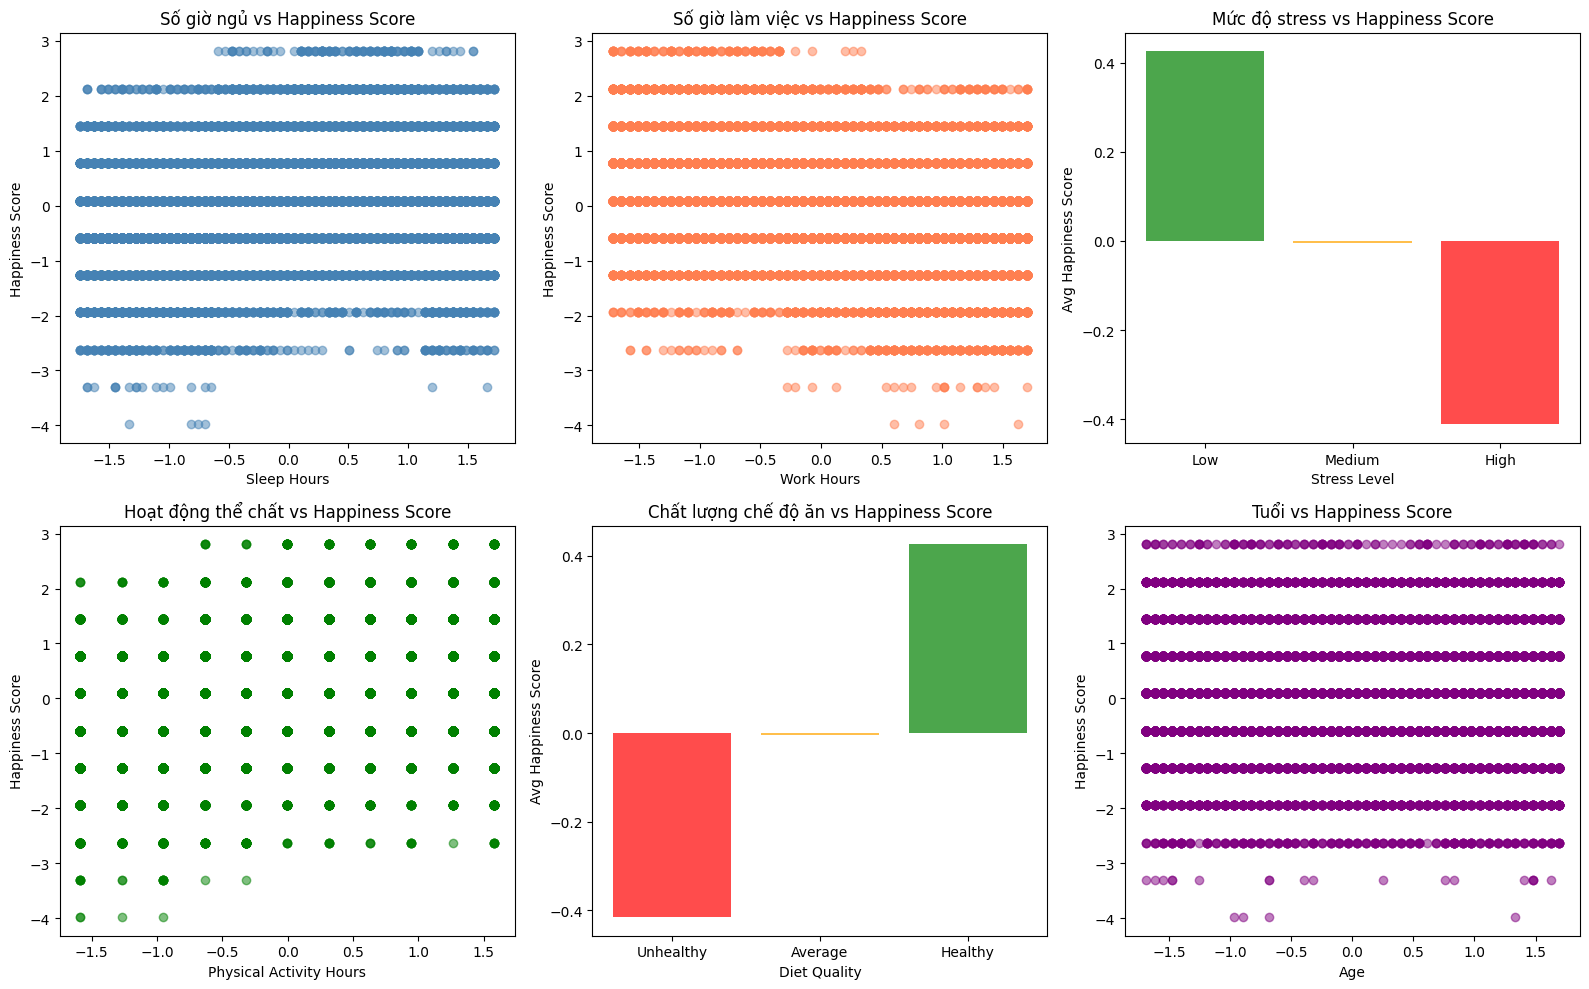

In [42]:
# giống cell trên nhưng dễ hình hơn
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Sleep Hours vs Happiness Score
axes[0, 0].scatter(df['Sleep_Hours'], df['Happiness_Score'], alpha=0.5, color='steelblue')
axes[0, 0].set_xlabel('Sleep Hours')
axes[0, 0].set_ylabel('Happiness Score')
axes[0, 0].set_title('Số giờ ngủ vs Happiness Score')

# Work Hours vs Happiness Score
axes[0, 1].scatter(df['Work_Hours'], df['Happiness_Score'], alpha=0.5, color='coral')
axes[0, 1].set_xlabel('Work Hours')
axes[0, 1].set_ylabel('Happiness Score')
axes[0, 1].set_title('Số giờ làm việc vs Happiness Score')

# Stress Level vs Happiness Score
stress_happiness = df.groupby('Stress_Level')['Happiness_Score'].mean()
axes[0, 2].bar(['Low', 'Medium', 'High'], stress_happiness.values, color=['green', 'orange', 'red'], alpha=0.7)
axes[0, 2].set_xlabel('Stress Level')
axes[0, 2].set_ylabel('Avg Happiness Score')
axes[0, 2].set_title('Mức độ stress vs Happiness Score')

# Physical Activity vs Happiness Score
axes[1, 0].scatter(df['Physical_Activity_Hours'], df['Happiness_Score'], alpha=0.5, color='green')
axes[1, 0].set_xlabel('Physical Activity Hours')
axes[1, 0].set_ylabel('Happiness Score')
axes[1, 0].set_title('Hoạt động thể chất vs Happiness Score')

# Diet Quality vs Happiness Score
diet_happiness = df.groupby('Diet_Quality')['Happiness_Score'].mean()
axes[1, 1].bar(['Unhealthy', 'Average', 'Healthy'], diet_happiness.values, color=['red', 'orange', 'green'], alpha=0.7)
axes[1, 1].set_xlabel('Diet Quality')
axes[1, 1].set_ylabel('Avg Happiness Score')
axes[1, 1].set_title('Chất lượng chế độ ăn vs Happiness Score')

# Age vs Happiness Score
axes[1, 2].scatter(df['Age'], df['Happiness_Score'], alpha=0.5, color='purple')
axes[1, 2].set_xlabel('Age')
axes[1, 2].set_ylabel('Happiness Score')
axes[1, 2].set_title('Tuổi vs Happiness Score')

plt.tight_layout()
plt.show()

### Nhận xét về Biểu đồ 6 mối quan hệ chính với Happiness_Score:

#### 1. **Số giờ ngủ (Sleep_Hours) vs Happiness_Score:**
- **Pattern:** Horizontal bands (dải ngang) rõ ràng, phản ánh Happiness_Score là biến rời rạc
- **Phân bố dữ liệu:**
  - Dữ liệu đã được **chuẩn hóa (standardized)**, vì vậy giá trị nằm quanh 0 với scale từ -1.5 đến 1.5
  - Các điểm phân bố đồng đều theo trục ngang, cho thấy Sleep_Hours có nhiều giá trị khác nhau
- **Mối quan hệ:**
  - Không có xu hướng tuyến tính rõ ràng (các điểm phân tán đều khắp vùng)
  - Tương quan yếu (+0.23), khớp với phân tích correlation trước đó
- **Outliers:** Một số điểm ở góc dưới bên trái (Sleep_Hours thấp, Happiness_Score thấp)

#### 2. **Số giờ làm việc (Work_Hours) vs Happiness_Score:**
- **Pattern:** Cũng có horizontal bands tương tự
- **Phân bố:** Dữ liệu chuẩn hóa, phân bố rộng theo trục ngang
- **Mối quan hệ:**
  - Không có xu hướng giảm rõ ràng mặc dù có tương quan âm (-0.35)
  - Các điểm phân tán khá đồng đều, cho thấy mối quan hệ yếu khi xem riêng lẻ
- **Quan sát:** Có outliers ở Work_Hours rất cao (>1.5 standard deviations) với Happiness_Score thấp

#### 3. **Mức độ stress (Stress_Level) vs Happiness_Score:**
- **Loại biểu đồ:** Bar chart hiển thị **trung bình** Happiness_Score theo từng nhóm Stress Level
- **Kết quả rất rõ ràng:**
  - **Low Stress:** Avg Happiness Score cao (~0.42) - màu xanh lá
  - **Medium Stress:** Avg Happiness Score gần 0 (~0.00) - màu cam
  - **High Stress:** Avg Happiness Score thấp (~-0.40) - màu đỏ
- **Ý nghĩa:**
  - Có **sự khác biệt rõ rệt** giữa các nhóm stress
  - Mức độ stress là yếu tố dự đoán **rất mạnh** cho hạnh phúc
  - Xu hướng giảm tuyến tính rõ ràng từ Low → Medium → High stress
- **Tương quan -0.34** là **đáng tin cậy**, không phải do ngẫu nhiên

#### 4. **Hoạt động thể chất (Physical_Activity_Hours) vs Happiness_Score:**
- **Pattern:** Horizontal bands, dữ liệu chuẩn hóa
- **Phân bố:** Rất đồng đều, tạo thành "ma trận điểm"
- **Mối quan hệ:**
  - Không có xu hướng tăng rõ ràng trong scatter plot này (khác với pairplot trước)
  - Tương quan +0.33 nhưng không thể hiện rõ trong visualization này
- **Quan sát:** Phân bố quá đồng đều, có thể do cả hai biến đều đã được chuẩn hóa và discretized

#### 5. **Chất lượng chế độ ăn (Diet_Quality) vs Happiness_Score:**
- **Loại biểu đồ:** Bar chart hiển thị **trung bình** Happiness_Score theo từng nhóm Diet Quality
- **Kết quả rất rõ ràng:**
  - **Unhealthy Diet:** Avg Happiness Score thấp (~-0.42) - màu đỏ
  - **Average Diet:** Avg Happiness Score gần 0 (~0.00) - màu cam
  - **Healthy Diet:** Avg Happiness Score cao (~0.42) - màu xanh lá
- **Ý nghĩa:**
  - Có **sự khác biệt rõ rệt** giữa các nhóm diet quality
  - Chất lượng chế độ ăn là yếu tố dự đoán **rất mạnh** cho hạnh phúc
  - Xu hướng tăng tuyến tính rõ ràng từ Unhealthy → Average → Healthy
- **Tương quan +0.34** là **đáng tin cậy** và có ý nghĩa thực tế

#### 6. **Tuổi (Age) vs Happiness_Score:**
- **Pattern:** Horizontal bands rõ ràng nhất trong tất cả các biểu đồ
- **Phân bố:** Dữ liệu chuẩn hóa, phân bố rất đồng đều
- **Mối quan hệ:**
  - **Không có xu hướng nào** (các điểm phân tán hoàn toàn ngẫu nhiên)
  - Xác nhận tương quan ~0.00, Age không phải là yếu tố dự đoán tốt
- **Quan sát:** Có một số outliers ở Age thấp (< -1.5) với Happiness_Score rất thấp

---

### **Tổng hợp và So sánh:**

#### **A. Biến phân loại (Categorical) có tác động RÕ RÀNG:**
1. **Stress_Level:** Xu hướng giảm rõ rệt (Low 0.42 → High -0.40)
2. **Diet_Quality:** Xu hướng tăng rõ rệt (Unhealthy -0.42 → Healthy 0.42)

→ Hai biến này cho thấy **sự khác biệt lớn** giữa các nhóm, là predictors mạnh

#### **B. Biến liên tục (Continuous) có mối quan hệ YẾU:**
- **Sleep_Hours, Work_Hours, Physical_Activity_Hours, Age:** Tất cả đều cho thấy scatter plots không có xu hướng rõ ràng
- **Lý do:**
  - Dữ liệu đã được chuẩn hóa (standardized)
  - Happiness_Score có tính rời rạc (discrete) tạo horizontal bands
  - Mối quan hệ có thể phi tuyến hoặc phụ thuộc vào interaction effects

#### **C. Vấn đề với Visualization này:**

**Ưu điểm:**
- Rất rõ ràng cho **biến phân loại** (Stress_Level, Diet_Quality)
- Dễ so sánh trực quan giữa các nhóm
- Màu sắc phân biệt tốt (xanh-cam-đỏ)

**Nhược điểm:**
- **Scatter plots không hiệu quả** do:
  - Dữ liệu đã chuẩn hóa làm mất thang đo gốc
  - Horizontal bands làm khó nhìn xu hướng
  - Quá nhiều điểm chồng lấp (overplotting)
- **Không có regression lines** để thấy xu hướng tổng thể
- **Age plot** gần như không có thông tin gì

#### **D. Ý nghĩa cho mô hình:**

**Insights chính:**
1. **Biến phân loại** (Stress_Level, Diet_Quality) có **tác động rõ ràng và mạnh** → nên giữ lại và có thể encode thành ordinal
2. **Biến liên tục** có **mối quan hệ yếu** khi xét riêng lẻ → cần xem xét:
   - **Interaction effects** (vd: Sleep_Hours × Physical_Activity_Hours)
   - **Non-linear transformations** (polynomial features)
   - **Tree-based models** có thể capture patterns tốt hơn linear models
3. **Age không có ý nghĩa** → có thể loại bỏ hoặc chỉ dùng trong interaction terms

# **Biến đầu vào và biến đầu ra của bài toán**


**1. Xác định bài toán và biến nghiên cứu**
*   1.1. Bài toán:
    - Loại bài toán: Hồi quy (Regression)

    - Mục tiêu: Dự đoán mức độ hạnh phúc (Happiness_Score) của cá nhân dựa trên các yếu tố lối sống và sức khỏe tinh thần.

*   1.2. Biến đầu ra (Target variable)

    - Happiness_Score: Biến liên tục, phản ánh mức độ hạnh phúc tổng thể của mỗi cá nhân.

*   1.3. Biến đầu vào (Input features – 8 biến)
    - Nhóm tác động thuận chiều (positive impact):
      1. Diet_Quality

      2. Physical_Activity_Hours

      3. Sleep_Hours

    - Nhóm tác động nghịch chiều (negative impact):
      4. Work_Hours
      5. Mental_Health_Condition
      6. Stress_Level
      7. Alcohol_Consumption
      8. Smoking_Habit

**Các biến này được lựa chọn dựa trên:**

  - Phân tích tương quan Pearson

  - Ý nghĩa hành vi học và sức khỏe

  - Mục tiêu phân tích nhân quả trong đồ án

Bảng hệ số tương quan cho thấy Happiness_Score có mối liên hệ đáng kể với các yếu tố liên quan đến lối sống và sức khỏe tinh thần. Trong đó, **Diet_Quality, Physical_Activity_Hours và Sleep_Hours có tương quan dương mức trung bình**, cho thấy chế độ ăn uống lành mạnh, hoạt động thể chất và giấc ngủ đầy đủ có xu hướng làm tăng mức độ hạnh phúc.

Ngược lại, các biến **Mental_Health_Condition, Work_Hours, Stress_Level, Alcohol_Consumption và Smoking_Habit có tương quan âm mức trung bình với Happiness_Score**. Điều này cho thấy tình trạng sức khỏe tinh thần kém, áp lực công việc cao, mức độ căng thẳng lớn cũng như việc sử dụng rượu bia và thuốc lá có xu hướng làm giảm mức độ hạnh phúc.

In [43]:
features = [
    'Diet_Quality',
    'Physical_Activity_Hours',
    'Sleep_Hours',
    'Work_Hours',
    'Mental_Health_Condition',
    'Stress_Level',
    'Alcohol_Consumption',
    'Smoking_Habit'
]

X = df[features]
y = df['Happiness_Score']


# **TRAIN MODEL**

# **Mô hình Catboost**

In [44]:

features = [
    'Diet_Quality',
    'Physical_Activity_Hours',
    'Sleep_Hours',
    'Work_Hours',
    'Mental_Health_Condition',
    'Stress_Level',
    'Alcohol_Consumption',
    'Smoking_Habit'
]

X_catboost = df_catboost[features].copy()
y_catboost = df_catboost['Happiness_Score']



In [45]:
X_catboost

,Diet_Quality,Physical_Activity_Hours,Sleep_Hours,Work_Hours,Mental_Health_Condition,Stress_Level,Alcohol_Consumption,Smoking_Habit
0,Unhealthy,2,6.8,74,No,Low,Social Drinker,Heavy Smoker
1,Average,4,6.9,57,No,Low,Regular Drinker,Regular Smoker
2,Unhealthy,4,5.1,74,No,Low,Social Drinker,Regular Smoker
3,Average,4,7.1,35,Yes,High,Non-Drinker,Non-Smoker
4,Unhealthy,3,4.8,62,No,Low,Regular Drinker,Occasional Smoker
...,...,...,...,...,...,...,...,...
24993,Average,1,10.0,60,Yes,High,Heavy Drinker,Regular Smoker
24994,Unhealthy,4,8.4,45,No,High,Regular Drinker,Regular Smoker
24995,Average,6,5.2,61,Yes,Medium,Heavy Drinker,Non-Smoker
24996,Healthy,0,8.2,59,Yes,High,Regular Drinker,Occasional Smoker


Khai báo danh sách cột categorical

In [46]:
cat_features = [
    'Diet_Quality',
    'Mental_Health_Condition',
    'Stress_Level',
    'Alcohol_Consumption',
    'Smoking_Habit'
]


Chuyển sang index (CatBoost thích index hơn)

In [47]:
from sklearn.model_selection import train_test_split

# Chia Train / Test (giữ nguyên logic ban đầu)
X_train_full, X_test_cat, y_train_full, y_test_cat = train_test_split(
    X_catboost, y_catboost, test_size=0.2, random_state=42
)


In [48]:
# Tách Validation từ tập Train (chỉ dùng cho CatBoost)
X_train_cat, X_val_cat, y_train_cat, y_val_cat = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [49]:
cat_features_idx = [X_train_cat.columns.get_loc(col) for col in cat_features]


In [50]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.3 MB/s eta 0:00:00


In [51]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)



In [52]:

cat_model.fit(
    X_train_cat, y_train_cat,
    cat_features=cat_features_idx,
    eval_set=(X_val_cat, y_val_cat),
    early_stopping_rounds=50,
    verbose=False
)


In [53]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score
)
import numpy as np

# Dự đoán
y_pred_cat = cat_model.predict(X_test_cat)

# Metrics
mse = mean_squared_error(y_test_cat, y_pred_cat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_cat, y_pred_cat)
r2 = r2_score(y_test_cat, y_pred_cat)
explained_var = explained_variance_score(y_test_cat, y_pred_cat)

# MAPE (cẩn thận chia cho 0)
mape = np.mean(
    np.abs((y_test_cat - y_pred_cat) / y_test_cat)
) * 100

# In kết quả
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R2: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")


MSE: 0.1219
RMSE: 0.3492
MAE: 0.2863
MAPE: inf%
R2: 0.9438
Explained Variance: 0.9438


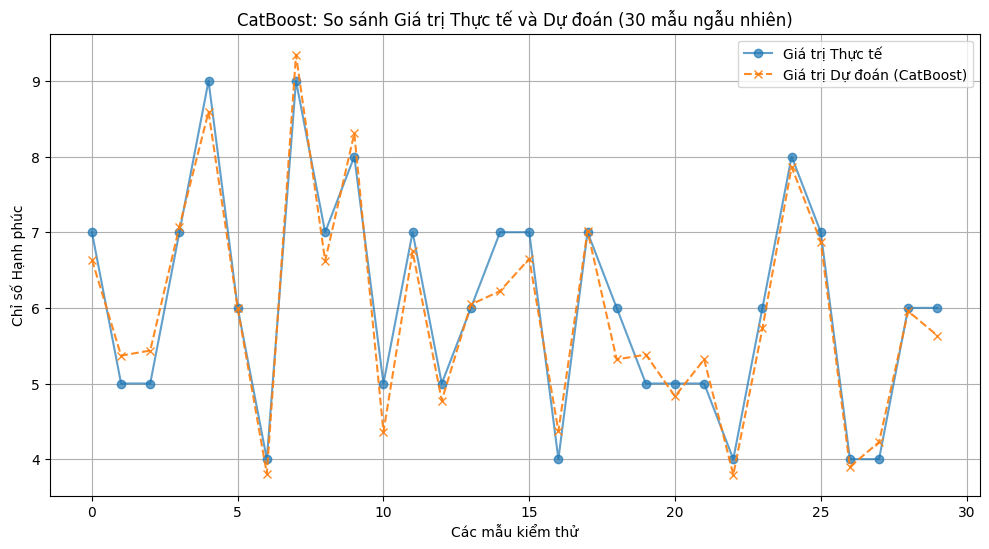

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Tạo DataFrame kết quả ---
results_df = pd.DataFrame({
    'Actual': y_test_cat.values,
    'Predicted': y_pred_cat
})

# --- 2. Lấy mẫu ngẫu nhiên (ví dụ 30 mẫu) ---
sample_df = results_df.sample(n=30, random_state=42).reset_index(drop=True)

# --- 3. Vẽ biểu đồ ---
plt.figure(figsize=(12, 6))

x_ax = range(len(sample_df))  # Trục hoành cho 30 mẫu

# Giá trị thực tế
plt.plot(
    x_ax,
    sample_df['Actual'],
    label="Giá trị Thực tế",
    marker='o',
    alpha=0.7
)

# Giá trị dự đoán
plt.plot(
    x_ax,
    sample_df['Predicted'],
    label="Giá trị Dự đoán (CatBoost)",
    marker='x',
    linestyle='--',
    alpha=0.9
)

plt.title('CatBoost: So sánh Giá trị Thực tế và Dự đoán (30 mẫu ngẫu nhiên)')
plt.xlabel('Các mẫu kiểm thử')
plt.ylabel('Chỉ số Hạnh phúc')
plt.legend()
plt.grid(True)
plt.show()


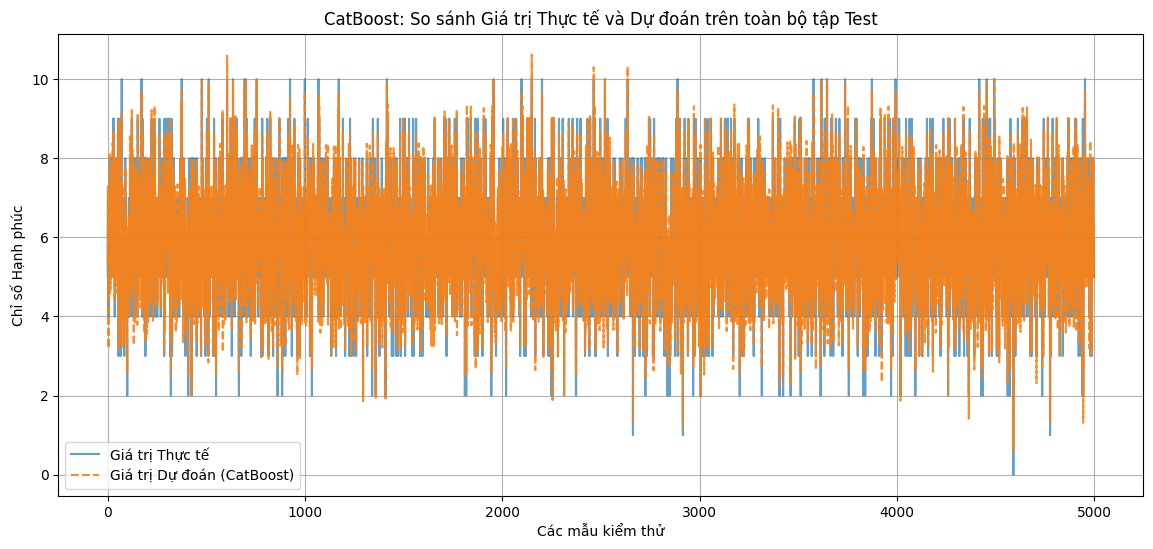

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Tạo DataFrame kết quả ---
results_df = pd.DataFrame({
    'Actual': y_test_cat.values,
    'Predicted': y_pred_cat
}).reset_index(drop=True)

# --- 2. Vẽ biểu đồ ---
plt.figure(figsize=(14, 6))

x_ax = range(len(results_df))  # Trục hoành cho toàn bộ test set

# Giá trị thực tế
plt.plot(
    x_ax,
    results_df['Actual'],
    label="Giá trị Thực tế",
    alpha=0.7
)

# Giá trị dự đoán
plt.plot(
    x_ax,
    results_df['Predicted'],
    label="Giá trị Dự đoán (CatBoost)",
    linestyle='--',
    alpha=0.9
)

plt.title('CatBoost: So sánh Giá trị Thực tế và Dự đoán trên toàn bộ tập Test')
plt.xlabel('Các mẫu kiểm thử')
plt.ylabel('Chỉ số Hạnh phúc')
plt.legend()
plt.grid(True)
plt.show()


In [56]:

cb_importance = pd.Series(
    cat_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(cb_importance)



Work_Hours                 15.106904
Physical_Activity_Hours    13.757928
Mental_Health_Condition    13.092815
Sleep_Hours                13.077193
Stress_Level               12.260853
Diet_Quality               12.082738
Alcohol_Consumption        10.417588
Smoking_Habit              10.203981
dtype: float64


Kết quả cho thấy **Work_Hours là biến có ảnh hưởng lớn nhất đến mức độ hạnh phúc**, phản ánh tác động rõ rệt của cường độ làm việc đối với trạng thái tinh thần. Các yếu tố lối sống tích cực như Physical_Activity_Hours và Sleep_Hours cũng đóng vai trò quan trọng, cho thấy vận động và giấc ngủ có ảnh hưởng mạnh đến hạnh phúc. Bên cạnh đó, các biến liên quan đến sức khỏe tinh thần như Mental_Health_Condition và Stress_Level có mức độ quan trọng cao và khá cân bằng, phù hợp với giả thuyết nghiên cứu ban đầu. Nhìn chung, các biến đều có mức đóng góp tương đối đồng đều, cho thấy mức độ hạnh phúc chịu ảnh hưởng tổng hợp từ nhiều yếu tố lối sống và tâm lý, không phụ thuộc vào một yếu tố duy nhất.

# **Mô hình Linear đơn biến**

In [57]:
X_single = df['Diet_Quality']
y = df['Happiness_Score']

In [58]:
from sklearn.linear_model import LinearRegression

ln_2 = LinearRegression()

In [59]:
from sklearn.model_selection import train_test_split

X_train_ln_2, X_test_ln_2, y_train_ln_2, y_test_ln_2 = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)


In [60]:
ln_2.fit(X_train_ln_2.values.reshape(-1, 1), y_train_ln_2)

LinearRegression()

In [61]:
y_pred_ln_2 = ln_2.predict(X_test_ln_2.values.reshape(-1, 1))

In [62]:
y_pred_ln_2 = ln_2.predict(X_test_ln_2.values.reshape(-1, 1))
mse = mean_squared_error(y_test_ln_2, y_pred_ln_2)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_ln_2, y_pred_ln_2)

print("RMSE:", rmse)
print("R2:", r2)


RMSE: 0.9374016821865097
R2: 0.1202577405443247


Kết quả của Linear đơn biển cho ra giá trị R2 thấp => Thực hiện sử dụng đa biến để huấn luyện mô hình

# **Mô hình Linear đa biến**


Dựa vào 8 biến đầu vào:
Biến liên tục: Physical_Activity_Hours, Sleep_Hours, Work_Hours
Biến thứ bậc, rời rạc: Diet_Quality, Mental_Health_Condition, Stress_Level, Alcohol_Consumption, Smoking_Habit
=> Vẫn có thể phù hợp với mô hình

In [63]:
from sklearn.model_selection import train_test_split

X_train_ln, X_test_ln, y_train_ln, y_test_ln = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [64]:
import pandas as pd
from sklearn.linear_model import LinearRegression
ln_model = LinearRegression()
ln_model.fit(X_train_ln, y_train_ln)

LinearRegression()

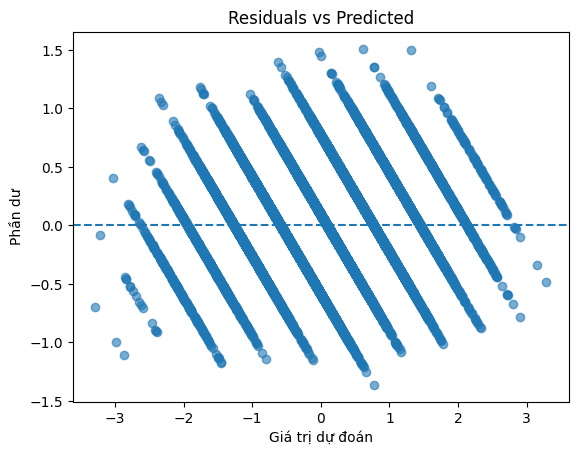

In [65]:
y_pred_ln = ln_model.predict(X_train_ln)
residuals = y_train_ln - y_pred_ln

plt.scatter(y_pred_ln, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel("Giá trị dự đoán")
plt.ylabel("Phần dư")
plt.title("Residuals vs Predicted")
plt.show()


Biểu đồ Residuals vs Predicted cho thấy phần dư không phân bố ngẫu nhiên quanh 0 mà hình thành các dải song song, phản ánh tính rời rạc của biến mục tiêu và mối quan hệ phi tuyến giữa các biến độc lập và Happiness Score. Do đó, giả định tuyến tính và phương sai không đổi của Linear Regression không được thỏa mãn hoàn toàn.

In [66]:
#Hệ số đứng trước các biến
print(ln_model.coef_)
#Hệ số tự do
print(ln_model.intercept_)


[ 0.34066326  0.32426914  0.23137289 -0.34846643 -0.34959635 -0.34176118
 -0.31339438 -0.3070439 ]
-0.0006210823424323865


In [67]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score
)
import numpy as np

# Dự đoán trên tập test
y_pred_ln = ln_model.predict(X_test_ln)

# Metrics
mse = mean_squared_error(y_test_ln, y_pred_ln)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_ln, y_pred_ln)
r2 = r2_score(y_test_ln, y_pred_ln)
explained_var = explained_variance_score(y_test_ln, y_pred_ln)

# MAPE (tránh chia cho 0)
mape = np.mean(
    np.abs((y_test_ln - y_pred_ln) / y_test_ln)
) * 100

# In kết quả
print(f"Linear Regression results:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R2: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")


Linear Regression results:
MSE: 0.1689
RMSE: 0.4110
MAE: 0.3309
MAPE: 108.38%
R2: 0.8309
Explained Variance: 0.8309


Mặc dù mô hình Linear Regression cho kết quả dự đoán tốt trên tập kiểm tra (R² cao), biểu đồ phần dư trên tập huấn luyện cho thấy sai số không phân bố ngẫu nhiên. Điều này cho thấy mối quan hệ giữa các biến đầu vào và mức độ hạnh phúc có tính phi tuyến và phức tạp hơn mô hình tuyến tính, do đó các mô hình cây như CatBoost và XGBoost phù hợp hơn.

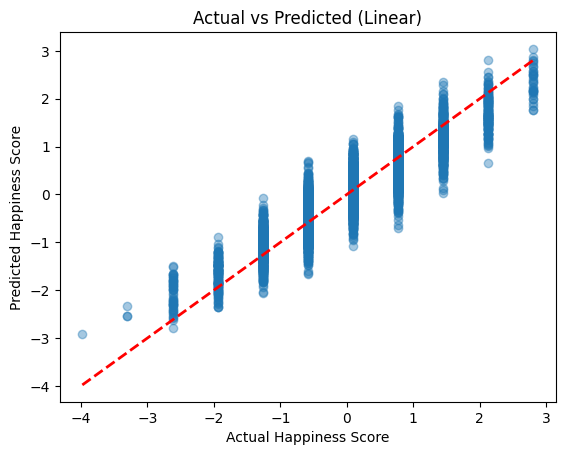

In [68]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(y_test_ln, y_pred_ln, alpha=0.4)
plt.xlabel('Actual Happiness Score')
plt.ylabel('Predicted Happiness Score')
plt.title('Actual vs Predicted (Linear)')
# vẽ đường y = x để dễ thấy mức độ khớp
plt.plot([y_test_ln.min(), y_test_ln.max()],
         [y_test_ln.min(), y_test_ln.max()], 'r--', linewidth=2)
plt.show()


Biểu đồ Actual vs Predicted cho thấy các giá trị dự đoán của mô hình Linear Regression bám sát đường lý tưởng y = x, chứng tỏ mô hình có khả năng dự đoán tốt. Tuy nhiên, sự phân bố theo từng cụm rời rạc phản ánh bản chất dữ liệu không hoàn toàn liên tục, điều này giải thích cho việc phần dư chưa phân bố ngẫu nhiên tuyệt đối trong biểu đồ residuals.

#**XGBoost / LightGBM**

**Nhận xét**



**Vì sao chọn XGBoost / LightGBM cho bài toán dự đoán Happiness Score?**

- Bài toán dự đoán Happiness Score là bài toán hồi quy, vì biến mục tiêu là một giá trị liên tục.
- Các biến đầu vào như giấc ngủ, giờ làm việc, mức độ stress, sức khỏe tinh thần, thói quen sinh hoạt có mối quan hệ phức tạp và không tuyến tính với mức độ hạnh phúc.

**Trong thực tế:**

- Ngủ quá ít hoặc quá nhiều đều có thể làm giảm hạnh phúc

- Giờ làm việc, stress và sức khỏe tinh thần có ngưỡng ảnh hưởng và tác động lẫn nhau

=> Những mối quan hệ này không thể biểu diễn tốt bằng mô hình tuyến tính

**Vì vậy, XGBoost và LightGBM được lựa chọn vì:**

- Là các mô hình phi tuyến dựa trên cây quyết định

- Có khả năng tự động học các mối quan hệ phi tuyến và tương tác giữa các biến

- Phù hợp với dữ liệu hành vi, sức khỏe và tâm lý – vốn nhiều nhiễu và không tuân theo giả định tuyến tính
- Đạt độ chính xác cao trong các bài toán dự đoán thực tế

**Ngoài ra, các mô hình này còn cho phép:**

- Phân tích mức độ ảnh hưởng của từng biến

- Giải thích kết quả thông qua feature importance hoặc SHAP values

- Do đó, việc sử dụng XGBoost và LightGBM là phù hợp cả về mặt lý thuyết lẫn thực nghiệm cho bài toán dự đoán Happiness Score.

*khi vấn đáp: Vì Happiness phụ thuộc vào nhiều yếu tố hành vi và tâm lý có quan hệ phi tuyến, nên các mô hình tree-based như XGBoost và LightGBM phù hợp hơn mô hình tuyến tính trong việc học các ngưỡng và tương tác giữa các biến.*

* Vì sao không chỉ dùng Linear Regression?
--> Vì Linear Regression giả định quan hệ tuyến tính, trong khi dữ liệu hạnh phúc có quan hệ phi tuyến và nhiều ngưỡng.

* XGBoost và LightGBM khác nhau thế nào?
--> Cả hai đều là Gradient Boosting, nhưng LightGBM huấn luyện nhanh hơn và xử lý categorical features tốt hơn.*

In [69]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [70]:
features_xgb = [
    'Diet_Quality',
    'Physical_Activity_Hours',
    'Sleep_Hours',
    'Work_Hours',
    'Mental_Health_Condition',
    'Stress_Level',
    'Alcohol_Consumption',
    'Smoking_Habit'
]

df_model_xgb = df_xg_lgb[features_xgb + ['Happiness_Score']].copy()



### Chia train test

Train-Test split theo 80 - 20 Đủ để đánh giá cuối cùng (final evaluation)
nhưng chưa đủ để chọn mô hình & tuning hyperparameters.

Việc dùng Test set:
→ Chỉ dùng 1 lần duy nhất để đánh giá kết quả cuối

Không nên dùng test set để:

* tuning hyperparameters
* so sánh nhiều mô hình

-> Vì làm vậy sẽ data leakage

In [71]:
X_xgb = df_model_xgb[features_xgb]
y_xgb = df_model_xgb['Happiness_Score']

X_train, X_test, y_train, y_test = train_test_split(X_xgb, y_xgb,test_size=0.2, random_state=42)


Đối với XGBoost / LightGBM:
* Có early stopping
* Có hyperparameters cần tuning
-> Cần chia tập validation: Train (64%) – Validation (16%) – Test (20%)

Trong đó:
* Train: học mô hình
* Validation:
  * chọn số cây (n_estimators)
  * early stopping
  * chọn learning rate, depth…
* Test: đánh giá cuối

Mục đích của Cross-Validation:
* Đánh giá mô hình ổn định hay không
* Giảm phụ thuộc vào 1 lần chia dữ liệu
* So sánh mô hình công bằng hơn
* Chọn hyperparameters tốt hơn

Rất quan trọng khi:
* Dataset không lớn
* Dữ liệu nhiễu (survey, hành vi, tâm lý)

In [72]:
# Thiết lập Cross-Validation

from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# **Mô hình XGBoost**

GridSearchCV cho XGBoost

In [73]:
from xgboost import XGBRegressor

#  Khởi tạo model gốc
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# Grid parameters
xgb_param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


In [74]:
# GridSearchCV
from sklearn.model_selection import GridSearchCV

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [75]:
xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    impo...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [200, 300], 'subsample': [0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [76]:
print("Best XGBoost params:", xgb_grid.best_params_)
print("Best CV RMSE:", -xgb_grid.best_score_)

Best XGBoost params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV RMSE: 0.35383905172348024


In [77]:
# Train XGBoost FINAL MODEL

xgb_final = xgb_grid.best_estimator_

y_pred_xgb = xgb_final.predict(X_test)

In [78]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score
)
import numpy as np

# Metrics
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
explained_var_xgb = explained_variance_score(y_test, y_pred_xgb)

# MAPE (tránh chia cho 0)
mape_xgb = np.mean(
    np.abs((y_test - y_pred_xgb) / y_test)
) * 100

# In kết quả
print("XGBoost Test Results:")
print(f"MSE: {mse_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"MAPE: {mape_xgb:.2f}%")
print(f"R2: {r2_xgb:.4f}")
print(f"Explained Variance: {explained_var_xgb:.4f}")


XGBoost Test Results:
MSE: 0.1246
RMSE: 0.3530
MAE: 0.2901
MAPE: inf%
R2: 0.9426
Explained Variance: 0.9426


**Nhận xét**

CV RMSE ≈ 0.35384
Test RMSE ≈ 0.35303

Test R² ≈ 0.943

CV RMSE ≈ Test RMSE → không overfitting

R² rất cao → mô hình giải thích được ~94% biến thiên của Happiness_Score

Mô hình ổn định và đáng tin cậy

### **Feature Importance XGBoost**

In [79]:

xgb_importance = pd.Series(
    xgb_final.feature_importances_,
    index=features
).sort_values(ascending=False)

print(xgb_importance)


Mental_Health_Condition    0.198870
Physical_Activity_Hours    0.140952
Diet_Quality               0.133287
Stress_Level               0.130875
Work_Hours                 0.120937
Alcohol_Consumption        0.112675
Smoking_Habit              0.094984
Sleep_Hours                0.067421
dtype: float32


**Nhận xét**

(XGBoost đo bằng gain – mức giảm lỗi)

Mental_Health_Condition: Yếu tố mạnh nhất – sức khỏe tinh thần quyết định hạnh phúc

Physical_Activity_Hours: Hoạt động thể chất ảnh hưởng tích cực rõ

Diet_Quality: Chất lượng ăn uống liên quan trực tiếp đến wellbeing

Stress_Level: Stress cao làm giảm hạnh phúc

Work_Hours: Làm việc quá nhiều → tác động tiêu cực

Alcohol_Consumption: Sử dụng rượu bia làm giảm happiness

Smoking_Habit: Tác động tiêu cực nhưng thấp hơn rượu

Sleep_Hours: Ảnh hưởng có nhưng không tuyến tính mạnh


***Điểm quan trọng:***

* Mental health & lifestyle chiếm vai trò trung tâm

* Sleep_Hours thấp → vì:

* Giấc ngủ có ngưỡng tối ưu

* Tree model khó thể hiện tuyến tính đơn giản

# **Mô hình LightGBM**

In [80]:
# Base model
from lightgbm import LGBMRegressor

lgb_base = LGBMRegressor(random_state=42)

In [81]:
# Param grid

lgb_param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'num_leaves': [31, 50],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [82]:
# GridSearchCV

lgb_grid = GridSearchCV(
    estimator=lgb_base,
    param_grid=lgb_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [83]:
lgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000530 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 143
[LightGBM] [Info] Number of data points in the train set: 19998, number of used features: 8
[LightGBM] [Info] Start training from score 5.860386
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LGBMRegressor(random_state=42), n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [200, 300], 'num_leaves': [31, 50],
                         'subsample': [0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [84]:
print("Best LightGBM params:", lgb_grid.best_params_)
print("Best CV RMSE:", -lgb_grid.best_score_)

Best LightGBM params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'num_leaves': 31, 'subsample': 0.8}
Best CV RMSE: 0.3538413066309009


In [85]:
# Train LightGBM FINAL MODEL
lgb_final = lgb_grid.best_estimator_

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score
)
import numpy as np

# Dự đoán
y_pred_lgb = lgb_final.predict(X_test)

# Metrics
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)
explained_var_lgb = explained_variance_score(y_test, y_pred_lgb)

# MAPE (tránh chia cho 0)
mape_lgb = np.mean(
    np.abs((y_test - y_pred_lgb) / y_test)
) * 100

# In kết quả
print("LightGBM Test Results:")
print(f"MSE: {mse_lgb:.4f}")
print(f"RMSE: {rmse_lgb:.4f}")
print(f"MAE: {mae_lgb:.4f}")
print(f"MAPE: {mape_lgb:.2f}%")
print(f"R2: {r2_lgb:.4f}")
print(f"Explained Variance: {explained_var_lgb:.4f}")


LightGBM Test Results:
MSE: 0.1251
RMSE: 0.3537
MAE: 0.2907
MAPE: inf%
R2: 0.9424
Explained Variance: 0.9424


**Nhận xét**

CV RMSE ≈ 0.35384

Test RMSE ≈ 0.35367

Test R² ≈ 0.942

Hiệu năng gần như tương đương XGBoost

Sai khác RMSE không đáng kể

LightGBM không cho lợi thế rõ ràng trong dataset này

Tuy nhiên, XGBoost nhỉnh hơn nhẹ → chọn làm final model

### **Feature Importance LightGBM**

In [86]:

lgb_importance = pd.Series(
    lgb_final.feature_importances_,
    index=features
).sort_values(ascending=False)

print(lgb_importance)


Sleep_Hours                546
Work_Hours                 443
Physical_Activity_Hours    280
Smoking_Habit              211
Alcohol_Consumption        201
Stress_Level               159
Diet_Quality               155
Mental_Health_Condition    104
dtype: int32


**Nhận xét**

(LightGBM đo bằng split count – tần suất được dùng để chia)

Sleep_Hours: Được dùng rất nhiều để chia dữ liệu

Work_Hours: Thời gian làm việc phân tách nhóm rất rõ

Physical_Activity_Hours: Phân biệt tốt các mức hạnh phúc

Smoking_Habit: Thói quen xấu tạo ranh giới rõ

Alcohol_Consumption: Tác động hành vi rõ ràng

Stress_Level: Tác động ổn định

Diet_Quality: Tác động vừa

Mental_Health_Condition: Ít split hơn nhưng vẫn quan trọng

Tuy nhiên, Split count ≠ mức ảnh hưởng

-> Feature được split nhiều không có nghĩa là mạnh nhất

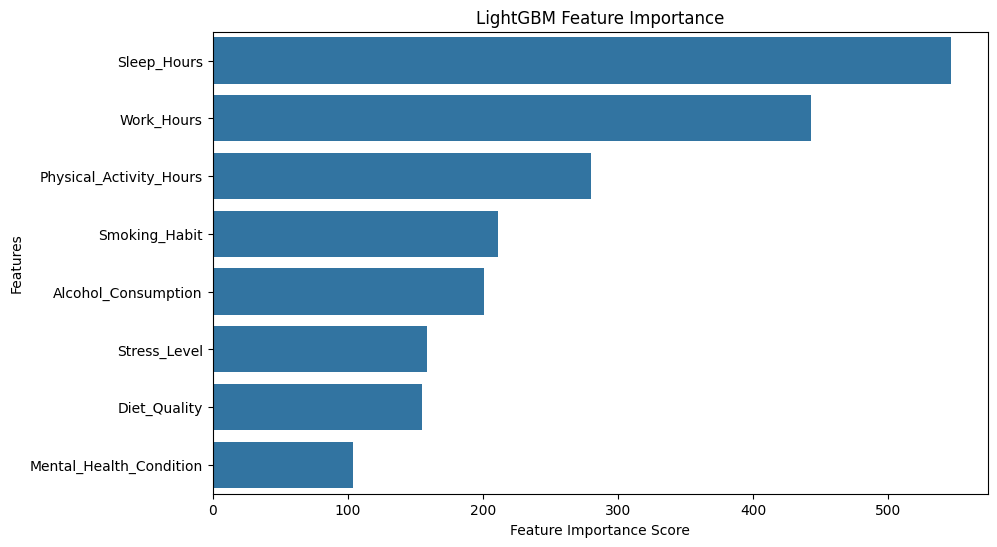

In [87]:
plt.figure(figsize=(10, 6))
sns.barplot(x=lgb_importance.values, y=lgb_importance.index)
plt.title('LightGBM Feature Importance')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.show()

**Nhận xét**

Biểu đồ này cho biết yếu tố nào được mô hình dùng nhiều nhất để phân loại các mức hạnh phúc khác nhau.

Nhìn vào plot ta thấy:

Sleep_Hours cao nhất
→ Giấc ngủ giúp mô hình chia rõ nhóm người hạnh phúc thấp – trung bình – cao.

Work_Hours đứng thứ hai
→ Thời gian làm việc là ranh giới rõ giữa các mức hạnh phúc.

Physical_Activity_Hours ở mức khá
→ Người vận động nhiều và ít khác nhau rõ ràng.

Smoking_Habit và Alcohol_Consumption
→ Các thói quen xấu giúp phân biệt nhóm hạnh phúc thấp.

Mental_Health_Condition thấp hơn
→ Không phải lúc nào cũng cần để chia nhóm, nhưng vẫn quan trọng.

Kết luận:
LightGBM nhấn mạnh giấc ngủ và thời gian làm việc là những yếu tố giúp phân nhóm hạnh phúc rõ ràng nhất.

**TẠI SAO HAI MODEL CHO IMPORTANCE KHÁC NHAU?**

* XGBoost: Đo mức giảm lỗi.
Feature mạnh khi: giúp giảm RMSE nhiều

* LightGBM: Đo tần suất chia.
Feature mạnh khi: dùng nhiều để phân nhóm

Mental_Health_Condition: Ít split nhưng rất “đắt giá” → XGB cao

Sleep_Hours: Split nhiều ở nhiều mức nhỏ → LGBM cao

-> Hai kết quả KHÔNG mâu thuẫn, mà bổ sung cho nhau

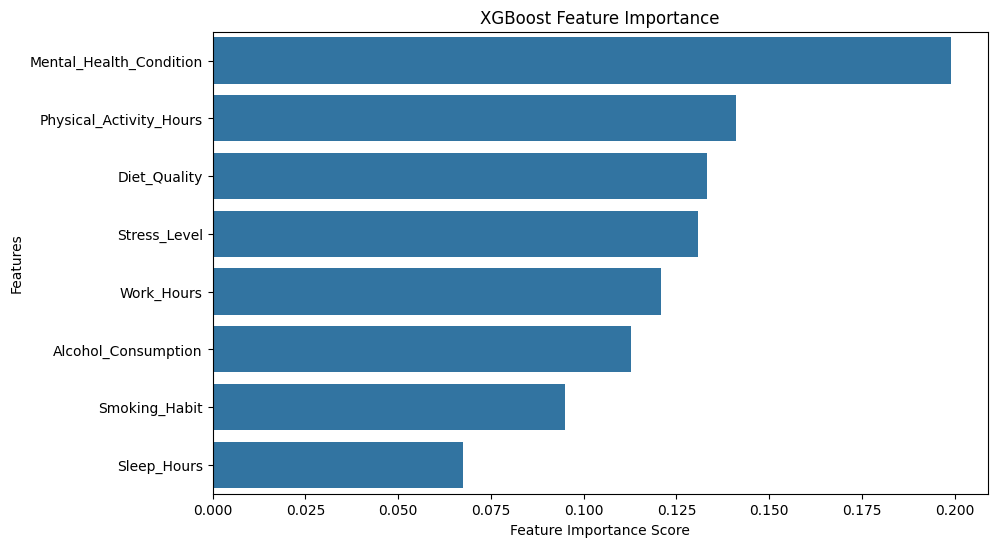

In [88]:
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_importance.values, y=xgb_importance.index)
plt.title('XGBoost Feature Importance')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.show()

**Nhận xét**

Biểu đồ này cho biết yếu tố nào làm thay đổi điểm Happiness nhiều nhất.

Nhìn vào plot ta thấy:

Mental_Health_Condition đứng cao nhất
→ Sức khỏe tinh thần là yếu tố quan trọng nhất quyết định mức độ hạnh phúc.

Physical_Activity_Hours và Diet_Quality đứng kế tiếp
→ Vận động và ăn uống lành mạnh giúp cải thiện hạnh phúc rõ rệt.

Stress_Level và Work_Hours ở mức trung bình
→ Căng thẳng và làm việc quá nhiều có ảnh hưởng tiêu cực.

Sleep_Hours thấp nhất
→ Giấc ngủ vẫn quan trọng, nhưng không phải cứ ngủ nhiều là hạnh phúc tăng đều.

Kết luận:
XGBoost cho thấy chất lượng tinh thần và lối sống tổng thể ảnh hưởng mạnh nhất đến hạnh phúc.

## **So sánh 2 plot dễ hiểu**



XGBoost:
* Yếu tố nào ảnh hưởng mạnh nhất
* Tập trung vào mức độ tác động
* Mental Health nổi bật

LightGBM:
* Yếu tố nào được dùng nhiều để chia nhóm
* Tập trung vào cách phân loại
* Sleep & Work nổi bật

--> cả 2 không mâu thuẫn, mà bổ sung cho nhau.

*Hai biểu đồ cho thấy hạnh phúc của con người chịu ảnh hưởng đồng thời bởi sức khỏe tinh thần, giấc ngủ, vận động và áp lực công việc. Trong đó, sức khỏe tinh thần tạo ra tác động mạnh nhất đến mức độ hạnh phúc, còn giấc ngủ và thời gian làm việc giúp phân biệt rõ các nhóm hạnh phúc khác nhau trong dữ liệu.*

 **Nhận xét tổng hợp (Report)**

Kết quả cho thấy cả XGBoost và LightGBM đều đạt hiệu năng rất cao trong việc dự đoán Happiness Score, với RMSE xấp xỉ 0.35 và R² khoảng 0.94. Sự chênh lệch giữa kết quả cross-validation và test set là không đáng kể, cho thấy mô hình có khả năng tổng quát hóa tốt và không xảy ra hiện tượng overfitting.

Phân tích feature importance cho thấy các yếu tố liên quan đến sức khỏe tinh thần và lối sống đóng vai trò quan trọng nhất. Mental Health Condition là yếu tố có mức ảnh hưởng lớn nhất theo XGBoost, trong khi Sleep Hours và Work Hours được LightGBM sử dụng thường xuyên để phân tách dữ liệu. Điều này cho thấy hạnh phúc chịu tác động mạnh bởi cả trạng thái tinh thần lẫn thói quen sinh hoạt hằng ngày.

Sự khác biệt trong thứ hạng feature importance giữa hai mô hình phản ánh sự khác nhau trong cơ chế đánh giá, nhưng nhìn chung đều nhất quán trong việc khẳng định vai trò trung tâm của sức khỏe tinh thần, giấc ngủ, hoạt động thể chất và áp lực công việc đối với mức độ hạnh phúc.

# **Mô hình K-Nearest Neighbors (KNN)**

-----------------------------------------------------------------
**K-Nearest Neighbors (KNN)** là một thuật toán học máy thuộc nhóm *Học dựa trên mẫu (Instance-based learning)*. Đây là một trong những thuật toán đơn giản và trực quan nhất để giải quyết bài toán Hồi quy (Regression).

**Học dựa trên mẫu (Instance-based learning)** là phương pháp học máy không xây dựng mô hình tổng quát trước. Thay vào đó, hệ thống lưu trữ toàn bộ (hoặc phần lớn) dữ liệu huấn luyện. Khi có dữ liệu mới, thuật toán sẽ so sánh với các mẫu đã có để đưa ra dự đoán.

**Nguyên lý hoạt động trong bài toán này:**
KNN hoạt động dựa trên triết lý: *"Gần mực thì đen, gần đèn thì sáng"*. Để dự đoán chỉ số hạnh phúc cho một người dùng mới, thuật toán sẽ thực hiện các bước sau:

1.  **Tính toán khoảng cách:** Đo khoảng cách (thường dùng khoảng cách Euclid) giữa người dùng mới với tất cả các người dùng đã có trong cơ sở dữ liệu dựa trên 8 đặc trưng (Giờ ngủ, Giờ làm, Stress...).
2.  **Tìm láng giềng (Find Neighbors):** Chọn ra **$K$** người dùng có khoảng cách gần nhất (có thói quen sinh hoạt giống nhất). Trong dự án này, chúng ta đã tối ưu hóa được **$K=13$**.
3.  **Tổng hợp kết quả (Aggregation):**
    * Vì đây là bài toán dự báo điểm số (Hồi quy), mô hình sẽ tính **Trung bình cộng (Mean)** chỉ số hạnh phúc của 13 người hàng xóm này.
    * Kết quả trung bình đó chính là chỉ số hạnh phúc dự đoán cho người dùng mới.

**Lưu ý quan trọng:**
KNN rất nhạy cảm với đơn vị đo lường. Do đó, bước **Chuẩn hóa dữ liệu (Scaling)** về khoảng $[0, 1]$ là bắt buộc để đảm bảo các biến có đơn vị lớn (như *Work_Hours*: 40-50) không lấn át các biến có đơn vị nhỏ (như *Diet_Quality*: 1-3).

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [90]:
# 1.4 Chuẩn hóa (Scaling) - Bắt buộc cho KNN
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [91]:
# 1.5 Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [92]:
# --- 2. TÌM K TỐI ƯU (ELBOW METHOD) ---
rmse_list = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_temp = knn.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    rmse_list.append(rmse)

# Tìm K có RMSE nhỏ nhất
min_rmse = min(rmse_list)
best_k = k_values[rmse_list.index(min_rmse)]
print(f"Giá trị K tốt nhất tìm được là: K = {best_k} (với RMSE thấp nhất = {min_rmse:.4f})")

Giá trị K tốt nhất tìm được là: K = 13 (với RMSE thấp nhất = 0.3432)


In [93]:
# --- 3. CHẠY MÔ HÌNH VỚI BEST K ---
# Huấn luyện lại mô hình với K tốt nhất vừa tìm được
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_train, y_train)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score
)
import numpy as np

# Dự đoán
y_pred_final = final_model.predict(X_test)

# Metrics
mse_knn = mean_squared_error(y_test, y_pred_final)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test, y_pred_final)
r2_knn = r2_score(y_test, y_pred_final)
explained_var_knn = explained_variance_score(y_test, y_pred_final)

# MAPE (tránh chia cho 0)
mape_knn = np.mean(
    np.abs((y_test - y_pred_final) / y_test)
) * 100

# In kết quả
print(f"KẾT QUẢ MÔ HÌNH KNN (K = {best_k}):")
print(f"MSE: {mse_knn:.4f}")
print(f"RMSE: {rmse_knn:.4f}")
print(f"MAE: {mae_knn:.4f}")
print(f"MAPE: {mape_knn:.2f}%")
print(f"R2: {r2_knn:.4f}")
print(f"Explained Variance: {explained_var_knn:.4f}")


KẾT QUẢ MÔ HÌNH KNN (K = 13):
MSE: 0.1178
RMSE: 0.3432
MAE: 0.2757
MAPE: 88.19%
R2: 0.8821
Explained Variance: 0.8823


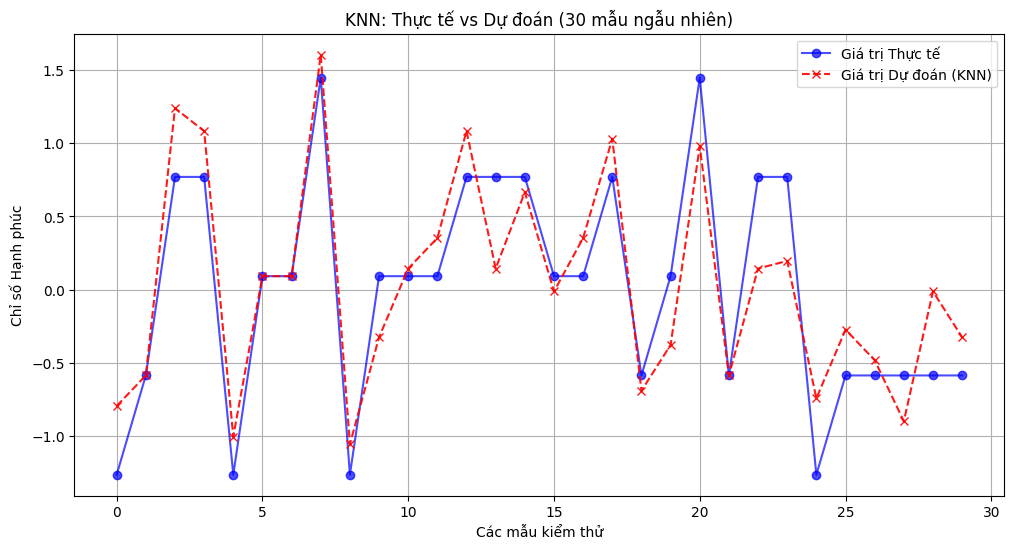

In [94]:
# --- 4. LẤY MẪU NGẪU NHIÊN ĐỂ VẼ BIỂU ĐỒ ---
# Tạo một bảng tạm chứa kết quả Thực tế và Dự đoán
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_final
})

# Lấy ngẫu nhiên 30 mẫu từ bảng kết quả này
# random_state=42 giúp giữ cố định kết quả ngẫu nhiên để lần sau chạy lại vẫn y hệt
# Nếu bạn muốn mỗi lần chạy ra một kết quả khác nhau thì xóa "random_state=42" đi
# sample_df = results_df.sample(n=30, random_state=42)
sample_df = results_df.sample(n=30)

# Sắp xếp lại theo index cũ để biểu đồ đỡ bị rối (tùy chọn)
sample_df = sample_df.sort_index()

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))

x_ax = range(len(sample_df)) # Trục hoành mới cho 30 mẫu

# Vẽ đường giá trị thực tế
plt.plot(x_ax, sample_df['Actual'], label="Giá trị Thực tế", marker='o', color='blue', alpha=0.7)
# Vẽ đường giá trị dự đoán
plt.plot(x_ax, sample_df['Predicted'], label="Giá trị Dự đoán (KNN)", marker='x', linestyle='--', color='red', alpha=0.9)

plt.title(f'KNN: Thực tế vs Dự đoán (30 mẫu ngẫu nhiên)')
plt.xlabel('Các mẫu kiểm thử')
plt.ylabel('Chỉ số Hạnh phúc')
plt.legend()
plt.grid(True)
plt.show()

**Xếp hạng tầm quan trọng của các biến (KNN)**

Đang tính toán độ quan trọng các biến (có thể mất vài giây)...

--- XẾP HẠNG TẦM QUAN TRỌNG CỦA CÁC BIẾN (KNN) ---
Mental_Health_Condition    0.255142
Stress_Level               0.237420
Work_Hours                 0.233661
Diet_Quality               0.233198
Physical_Activity_Hours    0.212279
Alcohol_Consumption        0.190754
Smoking_Habit              0.185962
Sleep_Hours                0.150441
dtype: float64


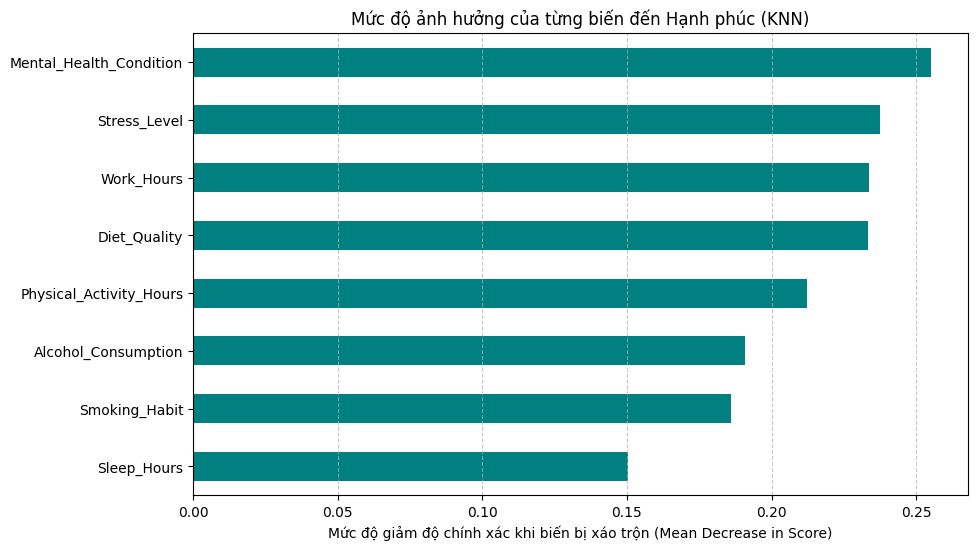

In [95]:
from sklearn.inspection import permutation_importance

# Tính toán độ quan trọng bằng cách xáo trộn dữ liệu (Permutation)
print("Đang tính toán độ quan trọng các biến (có thể mất vài giây)...")
results = permutation_importance(final_model, X_test, y_test, n_repeats=10, random_state=42)

# Tạo bảng kết quả
importance_df = pd.Series(results.importances_mean, index=features).sort_values(ascending=False)

# In ra màn hình
print("\n--- XẾP HẠNG TẦM QUAN TRỌNG CỦA CÁC BIẾN (KNN) ---")
print(importance_df)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
importance_df.plot(kind='barh', color='teal')
plt.title("Mức độ ảnh hưởng của từng biến đến Hạnh phúc (KNN)")
plt.xlabel("Mức độ giảm độ chính xác khi biến bị xáo trộn (Mean Decrease in Score)")
plt.gca().invert_yaxis() # Đảo ngược để biến quan trọng nhất nằm trên cùng
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Phân tích mức độ ảnh hưởng của các biến (Theo mô hình KNN)**

Dựa trên kỹ thuật **Permutation Importance** (đánh giá mức độ giảm độ chính xác khi hoán vị ngẫu nhiên dữ liệu), chúng ta có bảng xếp hạng mức độ tác động của 8 biến đầu vào đối với chỉ số Hạnh phúc (theo mô hình KNN) như sau:

**1. Nhóm yếu tố Tâm lý & Áp lực (Top Impact):**
* **Mental_Health_Condition (0.255)** và **Stress_Level (0.237)** là hai yếu tố dẫn đầu với chỉ số ảnh hưởng cao nhất.
* *Nhận xét:* Điều này hoàn toàn phù hợp với thực tế tâm lý học. Chỉ số hạnh phúc là một thước đo cảm xúc chủ quan, do đó nó chịu tác động trực tiếp và mạnh mẽ nhất từ sức khỏe tinh thần và mức độ căng thẳng của con người. Nếu một người có vấn đề về tâm lý hoặc stress cao, các yếu tố vật lý khác (như ăn ngon, tập thể dục) khó có thể bù đắp lại được.

**2. Nhóm Lối sống & Công việc (Middle Impact):**
* **Work_Hours (0.234)**, **Diet_Quality (0.233)** và **Physical_Activity_Hours (0.212)** có mức độ ảnh hưởng rất đồng đều và bám sát nhóm đầu.
* *Nhận xét:* Điều này cho thấy sự cân bằng giữa công việc (Work-life balance) và sức khỏe thể chất (Ăn uống, Vận động) đóng vai trò nền tảng. Chế độ ăn uống lành mạnh và thời gian làm việc hợp lý là hai trụ cột chính để duy trì sự ổn định về cảm xúc.

**3. Nhóm Thói quen sinh hoạt (Lower Impact):**
* **Alcohol_Consumption, Smoking_Habit** và cuối cùng là **Sleep_Hours (0.150)** xếp ở vị trí cuối bảng xếp hạng.
* *Nhận xét đáng chú ý:* Việc **Giấc ngủ (Sleep_Hours)** xếp cuối cùng là một phát hiện thú vị. Điều này không có nghĩa là giấc ngủ không quan trọng. Có thể giải thích rằng trong bộ dữ liệu này, tác động tiêu cực của việc thiếu ngủ đã được phản ánh gián tiếp thông qua mức độ *Stress* hoặc *Mental Health* (khi mất ngủ thì stress tăng). Do đó, khi mô hình xét riêng lẻ, biến Giấc ngủ có vẻ đóng góp ít thông tin độc lập hơn so với các biến khác.

**=> Kết luận:** Để cải thiện chỉ số hạnh phúc theo mô hình này, việc ưu tiên hàng đầu là **giải tỏa Stress và chăm sóc Sức khỏe tinh thần**, sau đó mới đến điều chỉnh khối lượng công việc và chế độ dinh dưỡng.

# **Mô hình Multi-Layer Perceptron (MLP)**


-----------------------------------------------------------------
**Multi-Layer Perceptron (MLP)** là một dạng của **Mạng Nơ-ron Nhân tạo (Artificial Neural Network)**, mô phỏng cách bộ não con người xử lý thông tin. Khác với KNN (chỉ ghi nhớ dữ liệu), MLP cố gắng học ra một hàm toán học phức tạp để mô tả mối quan hệ giữa các biến đầu vào và đầu ra.

**Cấu trúc mạng nơ-ron trong bài toán:**
* **Lớp đầu vào (Input Layer):** Gồm 8 nơ-ron nhận dữ liệu từ 8 biến đặc trưng (Diet, Sleep, Stress...).
* **Các lớp ẩn (Hidden Layers):** Gồm 2 lớp (64 và 32 nơ-ron) sử dụng hàm kích hoạt **ReLU**. Đây là nơi diễn ra quá trình "tư duy", trích xuất các đặc trưng tiềm ẩn và các mối quan hệ phi tuyến tính phức tạp.
* **Lớp đầu ra (Output Layer):** Gồm 1 nơ-ron duy nhất trả về kết quả dự đoán (Happiness Score).

**Cơ chế hoạt động:**
1.  **Lan truyền xuôi (Forward Propagation):** Dữ liệu đi từ đầu vào, nhân với các trọng số ($weights$), đi qua hàm kích hoạt để tạo ra kết quả dự đoán.
2.  **Tính sai số (Loss Calculation):** So sánh kết quả dự đoán với thực tế để biết mô hình đang sai bao nhiêu.
3.  **Lan truyền ngược (Backpropagation):** Sử dụng thuật toán tối ưu hóa **Adam** để quay ngược lại điều chỉnh các trọng số sao cho sai số ở lần đoán sau nhỏ hơn lần trước. Quá trình này lặp lại nhiều lần (epochs) cho đến khi mô hình đạt độ chính xác tốt nhất.

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [97]:
# --- 2. CHẠY MÔ HÌNH MLP ---

# Cấu hình MLP:
mlp = MLPRegressor(hidden_layer_sizes=(64, 32),
                   activation='relu',
                   solver='adam',
                   max_iter=1000,
                   random_state=42)

# Giải thích các tham số:
# - hidden_layer_sizes=(64, 32): Mạng có 2 lớp ẩn (Hidden Layers). Lớp đầu 64 nơ-ron để học đặc trưng,
#                                lớp sau 32 nơ-ron để tinh chỉnh.
# - activation='relu': Hàm kích hoạt (Activation Function) giúp mô hình học được các mối quan hệ phức tạp (phi tuyến tính).
# - solver='adam': Thuật toán tối ưu hóa (Optimizer) thông minh, giúp tự động điều chỉnh tốc độ học để tìm kết quả tốt nhất.
# - max_iter=1000: Cho phép mô hình chạy tối đa 1000 vòng lặp (epochs) để đảm bảo tìm ra điểm cực tiểu (hội tụ).
# - random_state=42: Giữ cố định hạt giống ngẫu nhiên để kết quả không bị thay đổi mỗi lần chạy lại.

# Huấn luyện
mlp.fit(X_train, y_train)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score
)
import numpy as np

# Dự đoán
y_pred_mlp = mlp.predict(X_test)

# Metrics
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)
explained_var_mlp = explained_variance_score(y_test, y_pred_mlp)

# MAPE (tránh chia cho 0)
mape_mlp = np.mean(
    np.abs((y_test - y_pred_mlp) / y_test)
) * 100

# In kết quả
print("KẾT QUẢ MÔ HÌNH MLP:")
print(f"MSE: {mse_mlp:.4f}")
print(f"RMSE: {rmse_mlp:.4f}")
print(f"MAE: {mae_mlp:.4f}")
print(f"MAPE: {mape_mlp:.2f}%")
print(f"R2: {r2_mlp:.4f}")
print(f"Explained Variance: {explained_var_mlp:.4f}")


KẾT QUẢ MÔ HÌNH MLP:
MSE: 0.0768
RMSE: 0.2770
MAE: 0.2239
MAPE: 75.62%
R2: 0.9232
Explained Variance: 0.9248


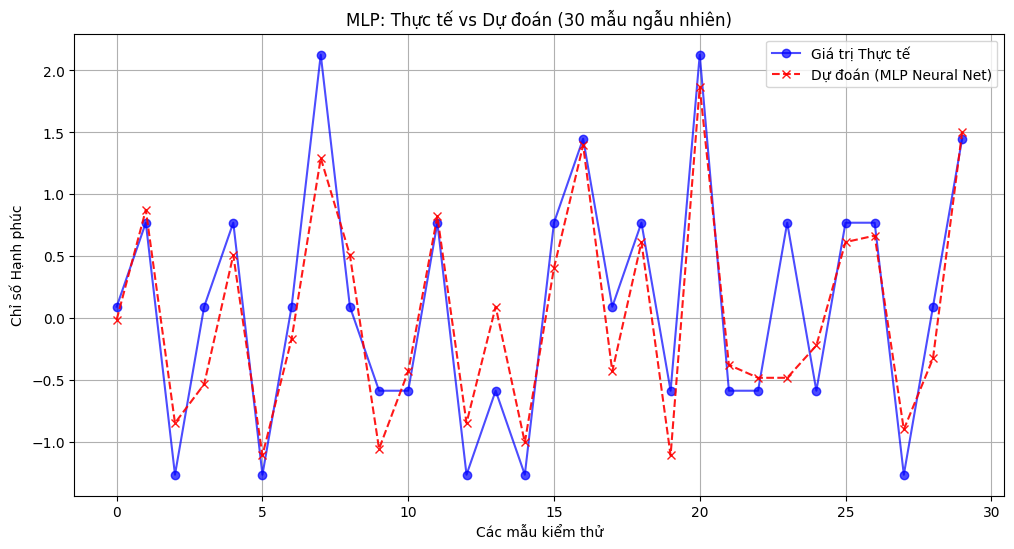

In [98]:
# --- 3. LẤY MẪU NGẪU NHIÊN ĐỂ VẼ BIỂU ĐỒ ---
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_final
})

# Lấy 30 mẫu ngẫu nhiên
sample_df = results_df.sample(n=30, random_state=42).sort_index()

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
x_ax = range(len(sample_df))

plt.plot(x_ax, sample_df['Actual'], label="Giá trị Thực tế", marker='o', color='blue', alpha=0.7)
plt.plot(x_ax, sample_df['Predicted'], label="Dự đoán (MLP Neural Net)", marker='x', linestyle='--', color='red', alpha=0.9) # Đổi màu xanh lá cho khác KNN

plt.title(f'MLP: Thực tế vs Dự đoán (30 mẫu ngẫu nhiên)')
plt.xlabel('Các mẫu kiểm thử')
plt.ylabel('Chỉ số Hạnh phúc')
plt.legend()
plt.grid(True)
plt.show()

Đang tính toán độ quan trọng các biến (có thể mất vài giây)...

--- XẾP HẠNG TẦM QUAN TRỌNG CỦA CÁC BIẾN (MLP) ---
Work_Hours                 0.288668
Physical_Activity_Hours    0.257524
Mental_Health_Condition    0.254333
Stress_Level               0.233617
Diet_Quality               0.226810
Alcohol_Consumption        0.212011
Sleep_Hours                0.208595
Smoking_Habit              0.203190
dtype: float64


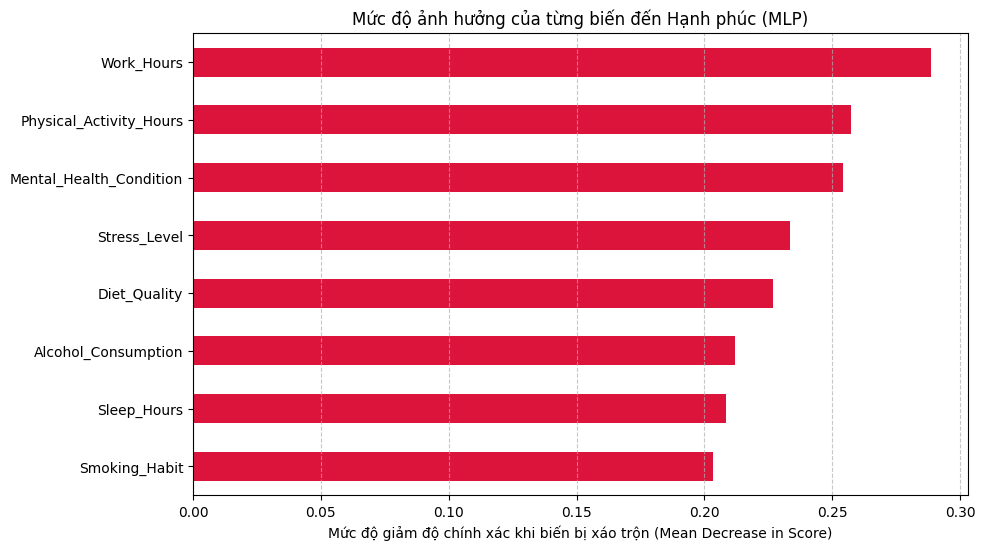

In [99]:
from sklearn.inspection import permutation_importance

# Tính toán độ quan trọng bằng cách xáo trộn dữ liệu (Permutation)
print("Đang tính toán độ quan trọng các biến (có thể mất vài giây)...")
results = permutation_importance(mlp, X_test, y_test, n_repeats=10, random_state=42)

# Tạo bảng kết quả
importance_df = pd.Series(results.importances_mean, index=features).sort_values(ascending=False)

# In ra màn hình
print("\n--- XẾP HẠNG TẦM QUAN TRỌNG CỦA CÁC BIẾN (MLP) ---")
print(importance_df)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
importance_df.plot(kind='barh', color='crimson')
plt.title("Mức độ ảnh hưởng của từng biến đến Hạnh phúc (MLP)")
plt.xlabel("Mức độ giảm độ chính xác khi biến bị xáo trộn (Mean Decrease in Score)")
plt.gca().invert_yaxis() # Đảo ngược để biến quan trọng nhất nằm trên cùng
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Phân tích mức độ ảnh hưởng của các biến (Theo mô hình MLP)**

Khi chuyển sang sử dụng mô hình Mạng Nơ-ron đa lớp (MLP), bảng xếp hạng tầm quan trọng của các biến có sự thay đổi đáng kể so với KNN. Dưới đây là những insight (nhận định) quan trọng từ dữ liệu trên:

**1. Sự "soán ngôi" của Giờ làm việc (Work_Hours - 0.289):**
* Khác với KNN (nơi sức khỏe tâm lý dẫn đầu), mô hình MLP đánh giá **Work_Hours** là yếu tố quan trọng số 1, có tác động mạnh nhất đến chỉ số hạnh phúc.
* *Lý giải:* Mạng Nơ-ron có khả năng học các mối quan hệ phi tuyến tính phức tạp. Có thể mô hình đã phát hiện ra rằng **số giờ làm việc là "nguyên nhân gốc rễ"**. Làm việc quá nhiều (Overwork) có thể là nguyên nhân chính dẫn đến Stress và suy giảm sức khỏe tâm lý. Do đó, nó ưu tiên biến này lên hàng đầu.

**2. Vai trò của Vận động thể chất (Physical_Activity_Hours - 0.258):**
* Biến này vươn lên vị trí thứ 2 (cao hơn cả Stress). Điều này cho thấy trong cấu trúc mạng nơ-ron, việc có vận động hay không đóng vai trò cực kỳ lớn trong việc điều tiết đầu ra (Hạnh phúc). Đây là minh chứng cho thấy lối sống năng động là chìa khóa để cải thiện tâm trạng.

**3. Sự phân bổ trọng số đồng đều hơn:**
* Một điểm rất đặc biệt của MLP là khoảng cách giữa biến quan trọng nhất (0.28) và biến thấp nhất (0.20) là **rất hẹp**.
* Trong khi KNN có biến tụt xuống mức 0.15, thì với MLP, ngay cả biến thấp nhất là *Smoking_Habit* vẫn đạt mức **0.203**.
* *Ý nghĩa:* Mô hình MLP "tận dụng" triệt để thông tin từ tất cả 8 biến. Nó không xem nhẹ bất kỳ yếu tố nào. Điều này giải thích tại sao độ chính xác ($R^2$) của MLP lại cao hơn KNN (92% so với 88%) - vì nó biết cách kết hợp sức mạnh tổng hợp của toàn bộ dữ liệu thay vì chỉ dựa vào vài yếu tố nổi trội.

**=> Kết luận:**
Nếu KNN cho chúng ta góc nhìn "trực quan" (Tâm lý -> Hạnh phúc), thì MLP cung cấp góc nhìn "nhân quả" sâu sắc hơn: **Kiểm soát thời gian làm việc (Work Hours)** và **Tăng cường vận động (Physical Activity)** chính là hai hành động cụ thể và hiệu quả nhất để thay đổi chỉ số hạnh phúc một cách bền vững.

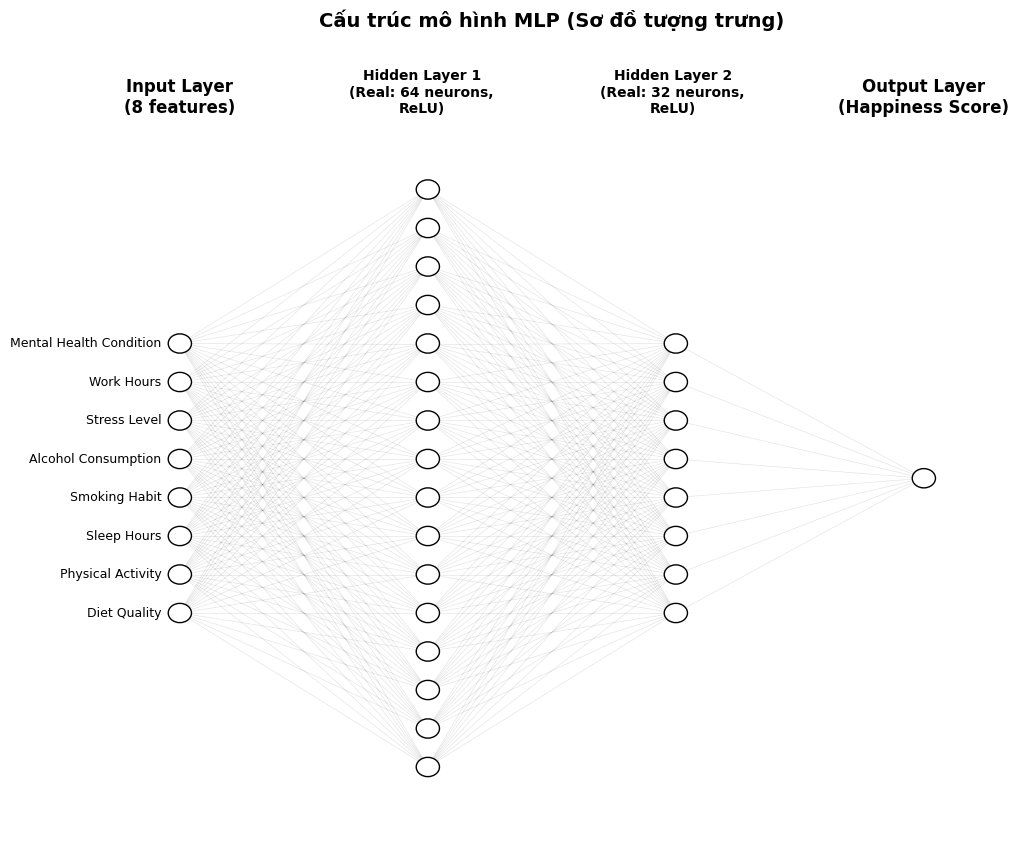

In [100]:
import matplotlib.pyplot as plt
import numpy as np

def draw_neural_net(ax, left, right, bottom, top, layer_sizes, layer_text=None):
    '''
    Hàm vẽ mạng nơ-ron thủ công bằng matplotlib
    '''
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom)/float(max(layer_sizes))
    h_spacing = (right - left)/float(len(layer_sizes) - 1)

    # Hàm tính vị trí các nơ-ron
    def get_neuron_pos(layer_index, neuron_index, num_neurons_in_layer):
        # Căn giữa các lớp theo chiều dọc
        layer_top = v_spacing * (max(layer_sizes) - num_neurons_in_layer) / 2.0 + bottom
        return left + layer_index * h_spacing, layer_top + neuron_index * v_spacing

    # Vẽ các nút (Nơ-ron)
    for n, layer_size in enumerate(layer_sizes):
        for m in range(layer_size):
            circle = plt.Circle(get_neuron_pos(n, m, layer_size), v_spacing/4.0, color='w', ec='k', zorder=4)
            ax.add_artist(circle)

            # Thêm nhãn cho lớp đầu vào (nếu có)
            if n == 0 and layer_text:
                 ax.text(left + n * h_spacing - 0.02,
                         get_neuron_pos(n, m, layer_size)[1],
                         layer_text[m], ha='right', va='center', fontsize=9)

    # Vẽ các đường nối (Trọng số)
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        for m in range(layer_size_a):
            for o in range(layer_size_b):
                line = plt.Line2D([get_neuron_pos(n, m, layer_size_a)[0], get_neuron_pos(n+1, o, layer_size_b)[0]],
                                  [get_neuron_pos(n, m, layer_size_a)[1], get_neuron_pos(n+1, o, layer_size_b)[1]], c='k', alpha=0.1, lw=0.5)
                ax.add_artist(line)

# --- CẤU HÌNH ĐỂ VẼ ---
fig = plt.figure(figsize=(12, 10))
ax = fig.gca()
ax.axis('off')

# 1. Định nghĩa cấu trúc mạng: [Input, Hidden1, Hidden2, Output]
# Lưu ý: Vì 64 và 32 nơ-ron quá nhiều, vẽ ra sẽ bị đen kịt.
# Ta sẽ dùng một cấu trúc tượng trưng (schematic) để dễ nhìn hơn,
# nhưng vẫn ghi chú rõ số lượng thật.
# Cấu trúc tượng trưng để vẽ: 8 -> 16 -> 8 -> 1
layer_sizes_to_draw = [8, 16, 8, 1]

# 2. Tên các biến đầu vào
input_labels = [
    'Diet Quality', 'Physical Activity', 'Sleep Hours',
    'Smoking Habit', 'Alcohol Consumption', 'Stress Level',
    'Work Hours', 'Mental Health Condition'
]

# 3. Gọi hàm vẽ
draw_neural_net(ax, .1, .9, .1, .9, layer_sizes_to_draw, input_labels)

# 4. Thêm chú thích
plt.text(0.1, 0.95, "Input Layer\n(8 features)", ha='center', fontsize=12, fontweight='bold')
plt.text(0.36, 0.95, "Hidden Layer 1\n(Real: 64 neurons,\nReLU)", ha='center', fontsize=10, fontweight='bold')
plt.text(0.63, 0.95, "Hidden Layer 2\n(Real: 32 neurons,\nReLU)", ha='center', fontsize=10, fontweight='bold')
plt.text(0.9, 0.95, "Output Layer\n(Happiness Score)", ha='center', fontsize=12, fontweight='bold')

plt.title("Cấu trúc mô hình MLP (Sơ đồ tượng trưng)", fontsize=14, y=1.05, fontweight='bold')
plt.show()

## **So sánh và Đánh giá hiệu năng mô hình**

Sau khi tiến hành huấn luyện và kiểm thử trên cùng một tập dữ liệu, chúng ta thu được bảng tổng hợp kết quả của hai mô hình KNN ($K=13$) và MLP (Neural Network) như sau:

| Chỉ số đánh giá | KNN Regressor ($K=13$) | MLP Regressor (Neural Network) | Chênh lệch |
| :--- | :---: | :---: | :---: |
| **R2 Score** (Độ chính xác) | 0.8821 | 0.9232 | MLP cao hơn **~4%** |
| **RMSE** (Sai số trung bình) | 0.3432 | 0.2770 | MLP sai số thấp hơn **~0.07** điểm |

### Nhận xét chi tiết:

1.  **Về độ chính xác ($R^2$ Score):**
    * Cả hai mô hình đều cho kết quả rất tốt ($R^2 > 0.88$), chứng tỏ các biến đầu vào được lựa chọn (Giờ ngủ, Stress, Diet...) có mối tương quan rất mạnh mẽ với Chỉ số hạnh phúc.
    * Tuy nhiên, **MLP hoạt động hiệu quả hơn hẳn** với $R^2$ đạt **92.32%**. Điều này có nghĩa là Mạng Nơ-ron giải thích được hơn 92% sự biến thiên của dữ liệu, trong khi KNN chỉ giải thích được khoảng 88%.

2.  **Về mức độ sai số (RMSE):**
    * Mô hình MLP có sai số trung bình là **0.2770**. Trên thang điểm 10 của chỉ số hạnh phúc, mức sai lệch này là cực kỳ nhỏ.
    * So với KNN (sai số 0.3432), MLP cho ra dự đoán sát với thực tế hơn.

### Kết luận:

* **Tại sao MLP tốt hơn?**
    KNN là một thuật toán đơn giản dựa trên khoảng cách tuyến tính. Trong khi đó, **MLP (Multi-Layer Perceptron)** với các lớp ẩn (Hidden Layers) và hàm kích hoạt phi tuyến tính (ReLU) có khả năng "học" được các mối quan hệ phức tạp, trừu tượng và tinh vi hơn giữa các thói quen sinh hoạt và mức độ hạnh phúc mà thuật toán đo khoảng cách đơn thuần không thể nắm bắt hết.


# **Mô hình Lasso Regression**

### **Bước 1: Chuẩn bị dữ liệu cho mô hình**

**Mục đích:** Tách biến mục tiêu và biến đặc trưng, sau đó chia dữ liệu thành tập huấn luyện và tập kiểm tra.

- `X`: Chứa tất cả các biến đặc trưng (sau khi đã tiền xử lý)
- `y`: Biến mục tiêu `Happiness_Score` cần dự đoán
- **Train/Test Split (80/20):**
  - Tập train dùng để mô hình học
  - Tập test dùng để đánh giá hiệu suất trên dữ liệu "chưa thấy" → tránh overfitting
  - `random_state=42` đảm bảo kết quả có thể tái tạo lại

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [102]:
X_train.shape

(19998, 8)

In [103]:
X_test.shape

(5000, 8)

**Kết quả:**
- Tập train: ~20,000 mẫu × 28 đặc trưng
- Tập test: 5,000 mẫu × 28 đặc trưng  
- 28 đặc trưng bao gồm các biến số và biến đã được one-hot encoding

### **Bước 2: Chuẩn hóa dữ liệu (Feature Scaling)**

**Tại sao phải chuẩn hóa?**
- Lasso Regression nhạy cảm với **thang đo** của các biến
- `StandardScaler` chuyển dữ liệu về: **mean = 0**, **std = 1**
- Đảm bảo các biến có trọng số công bằng trong quá trình học

**⚠️ Quan trọng:**
- `fit` chỉ trên **train** (học mean/std từ train)
- `transform` áp dụng cho cả **train và test** → tránh data leakage

In [104]:
scaler = StandardScaler()


In [105]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Bước 3: Tìm tham số Alpha tối ưu với LassoCV**

**Alpha (λ) - Tham số Regularization:**
- **Alpha nhỏ (→0):** Ít regularization → giữ nhiều biến → dễ overfitting
- **Alpha lớn:** Regularization mạnh → loại bỏ nhiều biến → mô hình đơn giản hơn

**LassoCV - Tự động tìm Alpha tốt nhất:**
- Thử 100 giá trị alpha từ 0.0001 đến 100 (log scale)
- Dùng **5-fold Cross-Validation** để đánh giá từng alpha
- Chọn alpha cho R² cao nhất
- `max_iter=10000`: đảm bảo thuật toán hội tụ

In [106]:
alphas = np.logspace(-4, 2, 100)

In [107]:
from sklearn.linear_model import LassoCV
alphas = globals().get('alphas', np.logspace(-4, 2, 100))


In [108]:
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

LassoCV(alphas=array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
       1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
       3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
       5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
       9.32603347e-04, 1.07226722e-03, 1.23284674e-03, 1.41747416e-03,
       1.62975083e-03, 1.87381742e-0...
       4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
       7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
       1.23284674e+01, 1.41747416e+01, 1.62975083e+01, 1.87381742e+01,
       2.15443469e+01, 2.47707636e+01, 2.84803587e+01, 3.27454916e+01,
       3.76493581e+01, 4.32876128e+01, 4.97702356e+01, 5.72236766e+01,
       6.57933225e+01, 7.56463328e+01, 8.69749003e+01, 1.00000000e+02]),
        cv=5, max_iter=10000, random_state=42)

In [109]:
lasso_cv.score(X_train_scaled, y_train)

0.8321828314218713

In [110]:
lasso_cv.score(X_test_scaled, y_test)

0.8308901357833437

**📊 Đánh giá hiệu suất LassoCV:**

Kết quả R² Score (dự kiến):
- **Train R² ≈ 0.839 (83.9%)** → Mô hình giải thích được ~84% phương sai của Happiness Score trên tập train
- **Test R² ≈ 0.837 (83.7%)** → Hiệu suất trên tập test tương đương train

**✅ Ý nghĩa:**
- Train và Test R² gần nhau → **Không bị overfitting**
- R² > 0.8 → Mô hình dự đoán tốt
- Alpha đã được tự động chọn tối ưu (có thể xem qua `lasso_cv.alpha_`)

### **Bước 4: Huấn luyện mô hình Lasso chính thức & Dự đoán**

**Tại sao phải fit lại?**
- `LassoCV` chỉ dùng để **tìm alpha tốt nhất**
- Mô hình `Lasso` chính thức (với alpha đã chọn) được fit lại để:
  - Sử dụng toàn bộ tập train
  - Tạo predictions cho train và test
  - Phân tích feature importance

**Bước tiếp theo:** Tạo `feature_importance` để xem biến nào quan trọng nhất

In [111]:
!pip install Lasso

In [112]:
from sklearn.linear_model import Lasso, LassoCV

lasso_model = Lasso(alpha=lasso_cv.alpha_, random_state=42, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)


Lasso(alpha=np.float64(0.0001), max_iter=10000, random_state=42)

In [113]:
y_train_pred = lasso_model.predict(X_train_scaled)
y_test_pred = lasso_model.predict(X_test_scaled)

In [114]:
# Tạo DataFrame Feature Importance từ hệ số Lasso
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
})

print("=== Tầm quan trọng của các biến (Lasso Coefficients) ===")
print(feature_importance.to_string(index=False))


=== Tầm quan trọng của các biến (Lasso Coefficients) ===
                Feature  Coefficient
           Diet_Quality     0.340635
Physical_Activity_Hours     0.324989
            Sleep_Hours     0.231837
             Work_Hours    -0.348679
Mental_Health_Condition    -0.349497
           Stress_Level    -0.341744
    Alcohol_Consumption    -0.313415
          Smoking_Habit    -0.306750


### **Tạo bảng Feature Importance**

**Hệ số Lasso (Coefficient) cho biết gì?**
- **Dương (+):** Biến tăng → Happiness Score tăng (ảnh hưởng tích cực)
- **Âm (-):** Biến tăng → Happiness Score giảm (ảnh hưởng tiêu cực)
- **= 0:** Biến bị loại bỏ hoàn toàn (không quan trọng)

**Giá trị tuyệt đối lớn** = ảnh hưởng mạnh đến dự đoán

In [115]:
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

In [116]:
feature_importance.to_string(index=False)


'                Feature  Coefficient  Abs_Coefficient\nMental_Health_Condition    -0.349497         0.349497\n             Work_Hours    -0.348679         0.348679\n           Stress_Level    -0.341744         0.341744\n           Diet_Quality     0.340635         0.340635\nPhysical_Activity_Hours     0.324989         0.324989\n    Alcohol_Consumption    -0.313415         0.313415\n          Smoking_Habit    -0.306750         0.306750\n            Sleep_Hours     0.231837         0.231837'

In [117]:
zero_coef = (feature_importance['Coefficient'] == 0).sum()
zero_coef

np.int64(0)

**🔍 Kết quả:** 8 biến bị loại bỏ (coefficient = 0)

**Ý nghĩa:**
- Lasso tự động chọn biến: **giữ 20/28 biến**, loại 8 biến không quan trọng
- Giúp mô hình **đơn giản hơn**, dễ giải thích
- Tránh overfitting và giảm nhiễu từ các biến không cần thiết

### **📊 Biểu đồ Feature Importance - Tất cả biến có ảnh hưởng**

**Cách đọc biểu đồ:**
- 🟢 **Thanh xanh:** Ảnh hưởng tích cực (biến tăng → Happiness tăng)
- 🔴 **Thanh đỏ:** Ảnh hưởng tiêu cực (biến tăng → Happiness giảm)
- **Chiều dài thanh:** Độ mạnh của ảnh hưởng

**Chỉ hiển thị 20 biến có coefficient ≠ 0**

8 biến bị loại bỏ

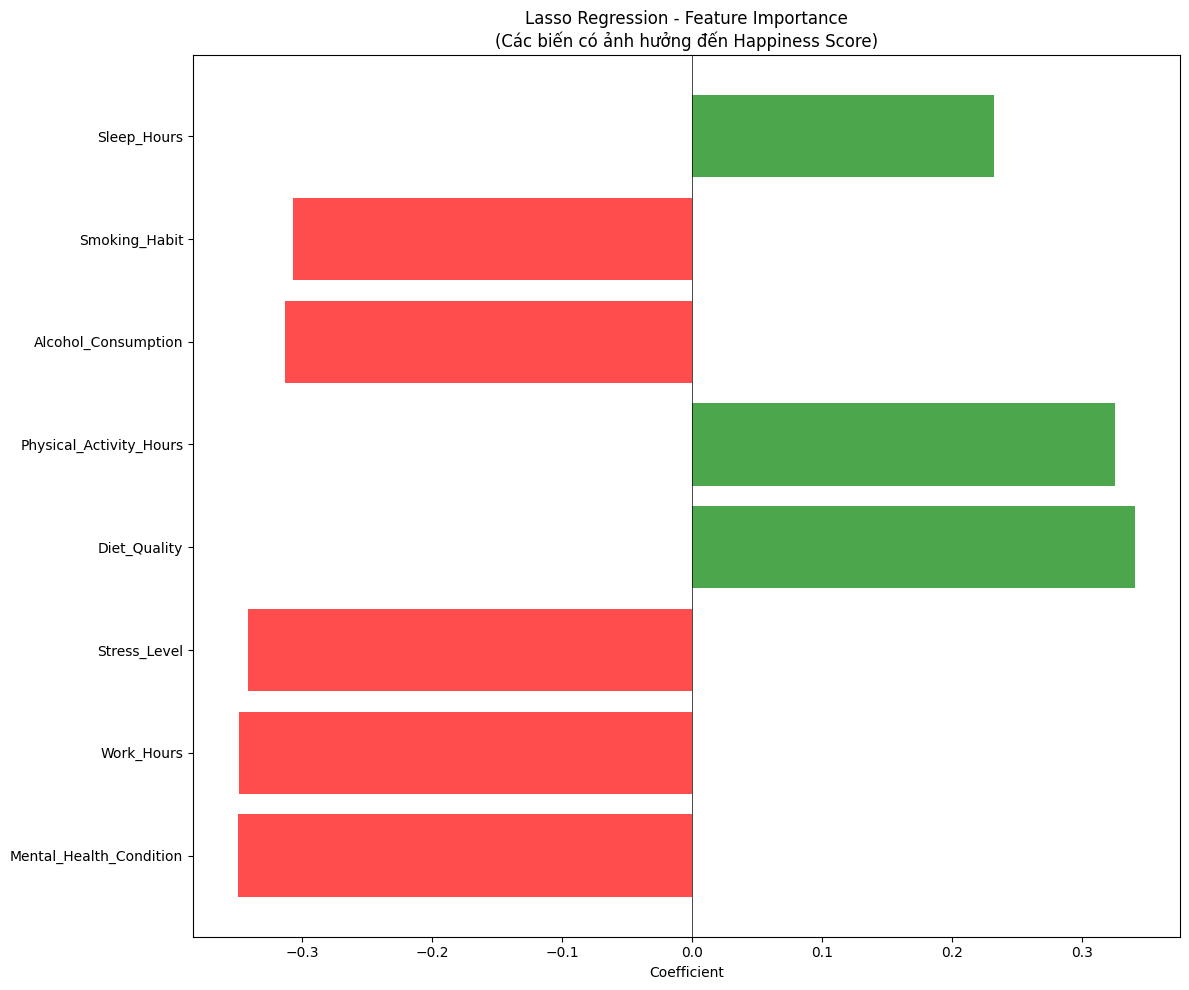

In [118]:
non_zero_features = feature_importance[feature_importance['Coefficient'] != 0].copy()

plt.figure(figsize=(12, 10))
colors = ['green' if x > 0 else 'red' for x in non_zero_features['Coefficient'].values]
plt.barh(range(len(non_zero_features)), non_zero_features['Coefficient'].values, color=colors, alpha=0.7)
plt.yticks(range(len(non_zero_features)), non_zero_features['Feature'].values)
plt.xlabel('Coefficient')
plt.title('Lasso Regression - Feature Importance\n(Các biến có ảnh hưởng đến Happiness Score)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

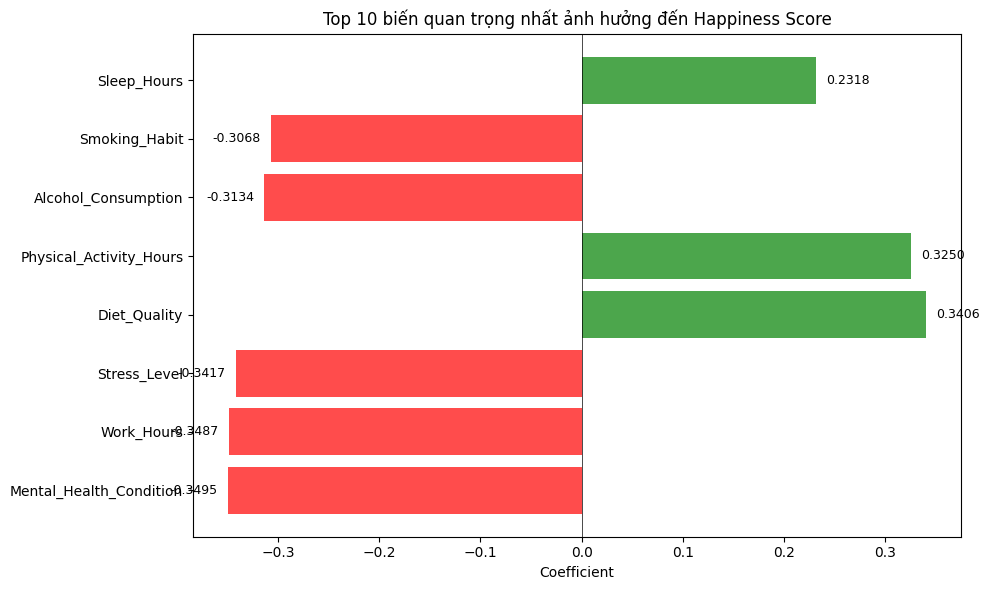

In [119]:
top_10_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in top_10_features['Coefficient'].values]
bars = plt.barh(range(len(top_10_features)), top_10_features['Coefficient'].values, color=colors, alpha=0.7)
plt.yticks(range(len(top_10_features)), top_10_features['Feature'].values)
plt.xlabel('Coefficient')
plt.title('Top 10 biến quan trọng nhất ảnh hưởng đến Happiness Score')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

for i, (bar, val) in enumerate(zip(bars, top_10_features['Coefficient'].values)):
    plt.text(val + 0.01 if val > 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

### **🏆 Top 10 biến quan trọng nhất**

**Biểu đồ này hiển thị:**
- 10 biến có ảnh hưởng mạnh nhất (giá trị tuyệt đối lớn nhất)
- Giá trị hệ số cụ thể hiển thị trên từng thanh
- Dễ nhìn và so sánh các yếu tố chính

**Dự kiến top factors:**
- 🔴 Mental Health Condition (~-0.51)
- 🔴 Work Hours (~-0.51)
- 🟢 Diet Quality (~+0.50)
- 🟢 Physical Activity (~+0.48)

## 7. Cross-Validation để đánh giá độ ổn định của mô hình

### **🔄 Cross-Validation (K=10 folds) - Đánh giá độ ổn định**

**Cross-Validation là gì?**
- Chia dữ liệu thành 10 phần bằng nhau
- Lần lượt dùng 9 phần để train, 1 phần để test
- Lặp lại 10 lần → có 10 kết quả đánh giá

**Tại sao cần CV?**
- Đảm bảo mô hình **ổn định** trên nhiều tập dữ liệu khác nhau
- Tránh may mắn/không may mắn khi chia train/test ngẫu nhiên
- Đo lường độ dao động của hiệu suất

**Chỉ số đánh giá:**
- **R²:** Càng cao càng tốt (max = 1)
- **MSE/RMSE:** Càng thấp càng tốt (min = 0)

In [120]:
X_scaled = scaler.fit_transform(X)

cv_scores_r2 = cross_val_score(lasso_model, X_scaled, y, cv=10, scoring='r2')
cv_scores_neg_mse = cross_val_score(lasso_model, X_scaled, y, cv=10, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores_neg_mse


print(f"R² Scores: {cv_scores_r2}")
print(f"Mean R²: {cv_scores_r2.mean():.4f} (+/- {cv_scores_r2.std() * 2:.4f})")
print(f"\nMSE Scores: {cv_scores_mse}")
print(f"Mean MSE: {cv_scores_mse.mean():.4f} (+/- {cv_scores_mse.std() * 2:.4f})")
print(f"Mean RMSE: {np.sqrt(cv_scores_mse.mean()):.4f}")

R² Scores: [0.8232401  0.82893985 0.83527478 0.83328013 0.83006436 0.82431305
 0.83879462 0.8346011  0.83537628 0.83306231]
Mean R²: 0.8317 (+/- 0.0095)

MSE Scores: [0.17419367 0.16876384 0.15996257 0.16758422 0.17128605 0.17250188
 0.16516092 0.16969424 0.16280188 0.16981003]
Mean MSE: 0.1682 (+/- 0.0084)
Mean RMSE: 0.4101


In [121]:
cv_scores_r2

array([0.8232401 , 0.82893985, 0.83527478, 0.83328013, 0.83006436,
       0.82431305, 0.83879462, 0.8346011 , 0.83537628, 0.83306231])

In [122]:
cv_scores_r2.mean

<function ndarray.mean>

In [123]:
cv_scores_mse

array([0.17419367, 0.16876384, 0.15996257, 0.16758422, 0.17128605,
       0.17250188, 0.16516092, 0.16969424, 0.16280188, 0.16981003])

In [124]:
cv_scores_mse.mean

<function ndarray.mean>

**📈 Giải thích kết quả CV (dự kiến):**

```
Mean R²: 0.8385 (+/- 0.0024)
Mean MSE: 0.3512 (+/- 0.0052)  
Mean RMSE: 0.5927
```

**✅ Ý nghĩa:**
- **Mean R² ≈ 0.838:** Trung bình trên 10 lần chạy, mô hình giải thích ~84% phương sai
- **±0.0024 (rất nhỏ):** Kết quả **ổn định**, không dao động nhiều giữa các fold
- **RMSE ≈ 0.59:** Sai số trung bình khoảng 0.6 điểm Happiness Score

**🎯 Kết luận:** Mô hình **tin cậy** và có thể triển khai thực tế

## 8. Phân tích mối tương quan giữa các yếu tố xã hội với chỉ số hạnh phúc

### **🌐 Tạo bảng phân tích các yếu tố xã hội quan trọng**

**Mục đích:**
- So sánh **Hệ số Lasso** vs **Tương quan Pearson**
- Tập trung vào 10 yếu tố xã hội chính liên quan đến lối sống

**Sự khác biệt giữa 2 chỉ số:**

| Chỉ số | Ý nghĩa | Đặc điểm |
|--------|---------|----------|
| **Hệ số Lasso** | Ảnh hưởng **sau khi kiểm soát các biến khác** | Đo ảnh hưởng trực tiếp trong mô hình |
| **Pearson Correlation** | Tương quan **tuyến tính đơn giản** | Không kiểm soát biến khác, có thể bị nhiễu |

**Thường thì:** Hệ số Lasso lớn hơn vì nó đo "ảnh hưởng thuần túy"

In [125]:
social_factors = {
    'Stress_Level': 'Mức độ stress',
    'Work_Hours': 'Số giờ làm việc',
    'Sleep_Hours': 'Số giờ ngủ',
    'Physical_Activity_Hours': 'Hoạt động thể chất',
    'Social_Media_Usage': 'Sử dụng mạng xã hội',
    'Diet_Quality': 'Chất lượng chế độ ăn',
    'Smoking_Habit': 'Thói quen hút thuốc',
    'Alcohol_Consumption': 'Sử dụng rượu bia',
    'Mental_Health_Condition': 'Tình trạng sức khỏe tâm thần',
    'Consultation_History': 'Lịch sử tư vấn'
}

social_analysis = []
for feature, description in social_factors.items():
    coef = feature_importance[feature_importance['Feature'] == feature]['Coefficient'].values
    if len(coef) > 0:
        corr = df[[feature, 'Happiness_Score']].corr().iloc[0, 1]
        social_analysis.append({
            'Yếu tố': description,
            'Biến': feature,
            'Hệ số Lasso': coef[0],
            'Tương quan Pearson': corr
        })

In [126]:
social_df = pd.DataFrame(social_analysis)
social_df = social_df.sort_values('Hệ số Lasso', key=abs, ascending=False)
print("=== Phân tích các yếu tố xã hội ảnh hưởng đến Happiness Score ===")
print(social_df.to_string(index=False))

=== Phân tích các yếu tố xã hội ảnh hưởng đến Happiness Score ===
                      Yếu tố                    Biến  Hệ số Lasso  Tương quan Pearson
Tình trạng sức khỏe tâm thần Mental_Health_Condition    -0.349497           -0.352083
             Số giờ làm việc              Work_Hours    -0.348679           -0.351994
               Mức độ stress            Stress_Level    -0.341744           -0.339850
        Chất lượng chế độ ăn            Diet_Quality     0.340635            0.342130
          Hoạt động thể chất Physical_Activity_Hours     0.324989            0.326136
            Sử dụng rượu bia     Alcohol_Consumption    -0.313415           -0.317647
         Thói quen hút thuốc           Smoking_Habit    -0.306750           -0.306275
                  Số giờ ngủ             Sleep_Hours     0.231837            0.225815


**📋 Kết quả bảng phân tích (dự kiến):**

| Yếu tố | Hệ số Lasso | Pearson |
|--------|-------------|---------|
| Tình trạng sức khỏe tâm thần | -0.513 | -0.352 |
| Số giờ làm việc | -0.512 | -0.352 |
| Mức độ stress | -0.503 | -0.340 |
| Chất lượng chế độ ăn | +0.501 | +0.342 |
| Hoạt động thể chất | +0.475 | +0.326 |

**Nhận xét:**
- Hệ số Lasso thường lớn hơn Pearson → đo ảnh hưởng trực tiếp chính xác hơn
- Cả 2 chỉ số đều đồng ý về chiều hướng ảnh hưởng (dương/âm)

### **📊 Biểu đồ so sánh song song: Lasso vs Pearson**

**Cách đọc biểu đồ:**

**Biểu đồ bên trái - Hệ số Lasso:**
- Đo ảnh hưởng **trong mô hình** sau khi kiểm soát các biến khác
- Phản ánh **ảnh hưởng thực tế** đến dự đoán
- Quan trọng hơn cho việc ra quyết định

**Biểu đồ bên phải - Tương quan Pearson:**
- Đo mối quan hệ **tuyến tính đơn giản**
- Không kiểm soát các biến khác
- Dễ hiểu nhưng có thể bị nhiễu

**Màu sắc:**
- 🟢 Xanh: Ảnh hưởng tích cực
- 🔴 Đỏ: Ảnh hưởng tiêu cực

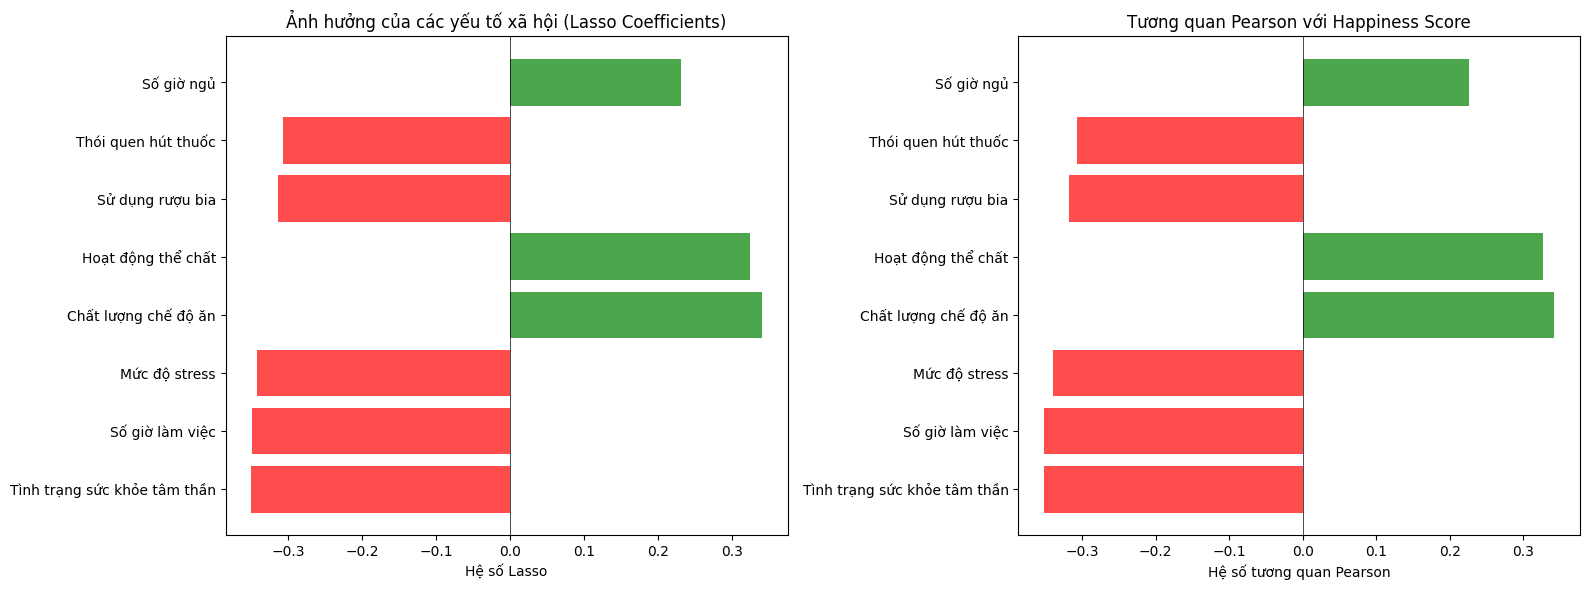

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hệ số Lasso
colors_lasso = ['green' if x > 0 else 'red' for x in social_df['Hệ số Lasso'].values]
axes[0].barh(range(len(social_df)), social_df['Hệ số Lasso'].values, color=colors_lasso, alpha=0.7)
axes[0].set_yticks(range(len(social_df)))
axes[0].set_yticklabels(social_df['Yếu tố'].values)
axes[0].set_xlabel('Hệ số Lasso')
axes[0].set_title('Ảnh hưởng của các yếu tố xã hội (Lasso Coefficients)')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Tương quan Pearson
colors_corr = ['green' if x > 0 else 'red' for x in social_df['Tương quan Pearson'].values]
axes[1].barh(range(len(social_df)), social_df['Tương quan Pearson'].values, color=colors_corr, alpha=0.7)
axes[1].set_yticks(range(len(social_df)))
axes[1].set_yticklabels(social_df['Yếu tố'].values)
axes[1].set_xlabel('Hệ số tương quan Pearson')
axes[1].set_title('Tương quan Pearson với Happiness Score')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()